In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 나만의 데이터로 모델 훈련시키기 - '커스텀 데이터셋' 제작법 (심층 분석편)]
#
# [개념적 개요 및 왜 이 작업을 하는가?]
# 딥러닝의 세계는 유명 셰프들이 미리 만들어 놓은 '유명 요리(MNIST, CIFAR10 등)'들로 가득 차 있습니다.
# 하지만 진정한 실력은 나만의 '특별한 재료(자신만의 데이터)'로 최고의 요리를 만들어낼 때 증명됩니다.
# '커스텀 데이터셋' 클래스를 만드는 것은, 우리 회사 제품 이미지, 고객 리뷰 텍스트, 공장 센서 데이터 등
# 세상에 단 하나뿐인 우리만의 재료를 PyTorch라는 '최첨단 요리 기계'가 이해할 수 있는 '표준 규격의 밀키트'로
# 정성껏 포장하는 방법을 배우는 것입니다.
# 이 포장 기술(Custom Dataset)을 마스터해야만, 대량의 밀키트를 빠르고 효율적으로 주방에 공급하는
# '컨베이어 벨트 시스템(DataLoader)'을 가동할 수 있습니다. 즉, 이 작업은 나만의 AI를 만들기 위한
# 가장 근본적이고 필수적인 첫걸음입니다.
#
# [핵심 비유: 레스토랑 주방의 시스템]
# 딥러닝의 데이터 파이프라인은 잘 짜인 레스토랑의 주방과 같습니다.
#
# 1. `Dataset` 클래스 (이 코드의 주인공): '주방의 레시피북이자 식료품 저장고'
#    - 역할: 이 레스토랑이 어떤 메뉴(데이터)들을 가지고 있는지, 그리고 각 메뉴를 어떻게 '하나씩'
#            만들어야 하는지에 대한 모든 정보를 담고 있는, 레스토랑의 심장과도 같은 존재입니다.
#    - `__init__`: "개업 준비". 레스토랑을 열 때 단 한 번, 모든 재료(데이터 파일 경로, 데이터 리스트 등)를
#                  저장고에 들여놓고 정리하는, 가장 먼저 이루어지는 신성한 의식입니다.
#    - `__len__`: "메뉴판의 총 가짓수". "우리 레스토랑은 총 몇 종류의 요리를 팔고 있나요?"라는 외부의 질문에
#                 정확한 숫자를 알려주는, 레스토랑의 규모를 나타내는 지표입니다.
#    - `__getitem__`: "숙련된 요리사". "3번 메뉴 하나 만들어주세요!"라는 주문(index)을 받으면, 저장고에서
#                     정확한 재료를 꺼내고(데이터 로드), 레시피에 따라 정성껏 요리하여(전처리), 모델이 바로 먹을 수 있는
#                     최상의 상태(텐서 변환)로 '요리 한 접시'를 내어주는 핵심적인 역할입니다.
#
# 2. `DataLoader` 클래스 (다음 단계): '민첩한 서빙 직원'
#    - 역할: 주방(`Dataset`)에 가서, 여러 개의 요리(`__getitem__` 반복 호출)를 한 번에 쟁반(배치, Batch)에
#            담아 손님(모델)에게 효율적으로 서빙합니다.
#
# [지금 무엇을 하고 있는가?]
# 바로 이 '레시피북이자 식료품 저장고'인 `Dataset` 클래스를 직접 설계하고 제작하는 과정을 배우고 있습니다.
# PyTorch와의 약속인 세 가지 필수 규칙(`__init__`, `__len__`, `__getitem__`)을 구현하여,
# 우리만의 데이터를 위한 맞춤형 공급 시스템의 심장을 만드는, 가장 창의적이고 중요한 단계에 있습니다.
# ====================================================================================================


# --- 1. 기본 도구 준비: 라이브러리 불러오기 ---
# [흐름] 본격적인 '밀키트' 제작에 앞서, 필요한 핵심 도구들을 작업대로 가져오는 과정입니다.

# [구동 과정 심층 분석] `import torch`
# 1. 파이썬 인터프리터가 `import torch`라는 명령을 읽습니다.
# 2. 인터프리터는 설치된 파이썬 라이브러리 경로에서 'torch'라는 이름의 패키지를 찾습니다.
# 3. 성공적으로 찾으면, 해당 패키지의 코드를 메모리로 불러와 초기화하고, `torch`라는 이름으로 현재 스크립트에서 접근할 수 있도록 준비합니다.
#    이제 우리는 `torch.tensor`, `torch.nn` 등 torch 패키지가 제공하는 방대한 기능을 사용할 수 있는 상태가 되었습니다.
import torch

# [구동 과정 심층 분석] `from torch.utils.data import Dataset`
# 1. 파이썬 인터프리터가 `from ... import ...` 구문을 읽습니다. 이는 패키지 전체가 아닌, 특정 부품만 가져오겠다는 의미입니다.
# 2. 먼저 `torch` 패키지를 찾고, 그 안의 `utils`라는 하위 모듈, 또 그 안의 `data`라는 하위 모듈까지 경로를 따라 들어갑니다.
# 3. `data` 모듈 내부에 정의된 여러 도구들 중에서, `Dataset`이라는 이름의 '클래스(설계도)'만 정확히 콕 집어 현재 스크립트로 가져옵니다.
#    이제 우리는 `torch.utils.data.Dataset`이라고 길게 쓸 필요 없이, `Dataset`이라는 이름만으로 이 설계도를 사용할 수 있습니다.
from torch.utils.data import Dataset

In [ ]:
# --- 2. [핵심] 커스텀 데이터셋 클래스(밀키트 설계도) 정의 ---
# [흐름] 우리만의 데이터를 담을 '밀키트'의 설계도를 직접 그리는 과정입니다. PyTorch가 정해놓은 3가지 필수 규칙을 지켜야 합니다.

# [구동 과정 심층 분석] `class CustomDataset(Dataset):`
# 1. `class` 키워드를 통해, `CustomDataset`이라는 이름의 새로운 '클래스(객체 설계도)'를 정의하기 시작합니다.
# 2. `(Dataset)` 부분은 '상속'을 의미합니다.
#    "우리가 만들 `CustomDataset`은 방금 import한 `Dataset` 설계도의 모든 특징과 규칙을 물려받겠습니다"라는 선언입니다.
#    - **왜 상속이 중요한가?**: `DataLoader`와 같은 PyTorch의 다른 도구들은 `Dataset`이라는 표준 규격을 따르는 객체와만 소통하도록 설계되었습니다.
#      상속을 통해 우리 `CustomDataset`도 이 표준 규격을 따른다는 '인증 마크'를 받게 되어, PyTorch 생태계 안에서 완벽하게 호환됩니다.
class CustomDataset(Dataset):
    # --- [필수 규칙 1: `__init__` - 초기 설정 (재료 창고 채우기)] ---
    # [개념 심층 분석] 이 메서드는 클래스의 '생성자(constructor)'입니다. `CustomDataset()`처럼 객체를 '생성'하는 순간,
    #                마치 아기가 태어날 때 기본적인 신체 기관이 형성되듯, 객체가 존재하기 위해 필요한 최소한의 설정을 수행합니다.
    #                이 과정은 객체의 일생에서 단 한 번뿐이며, 객체가 살아있는 동안 계속해서 사용해야 할
    #                초기 자산(데이터, 설정값 등)을 마련하는 역할을 합니다.
    #
    # [구동 과정 심층 분석] `def __init__(self):`
    # 1. `__init__`이라는 특별한 이름의 메서드를 정의합니다. 이 이름은 파이썬과의 약속으로, '객체 생성 시 자동 호출'을 의미합니다.
    # 2. `self` 매개변수는 매우 중요합니다. 이것은 앞으로 이 설계도를 통해 만들어질 '객체 인스턴스 그 자체'를 가리키는 대명사입니다.
    #    `my_dataset = CustomDataset()` 코드가 실행될 때, `__init__` 내부의 `self`는 바로 `my_dataset`을 의미하게 됩니다.
    def __init__(self):
        # [지금 무엇을 하고 있는가?]
        # 레스토랑 개업을 위해, 앞으로 판매할 모든 메뉴의 '주재료'와 '정답 소스'를 레시피북에 기입하고,
        # 거대한 식료품 저장고에 정리해 넣는 작업을 하고 있습니다.
        # 이 작업은 개업 첫날 한 번만 해두면, 이후에는 계속해서 꺼내 쓰기만 하면 됩니다.

        # [구동 과정 심층 분석] `self.x = [...]`
        # 1. `[[10, 20], [11, 20], ...]` 라는 2차원 구조의 파이썬 리스트가 컴퓨터 메모리의 한 공간에 생성됩니다.
        # 2. `=` 할당 연산자는 오른쪽에 있는 것을 왼쪽의 변수에 저장하라는 의미입니다.
        # 3. `self.x`는 " `self` 라는 객체에 `x` 라는 이름표를 붙여 이 데이터를 저장해줘" 라는 의미입니다.
        #    이 과정을 통해, 메모리에 생성된 리스트는 이제 이 객체만의 고유한 '속성(attribute)' 또는 '인스턴스 변수'가 됩니다.
        #    이제 이 데이터는 객체가 사라지기 전까지는 계속해서 `self.x`라는 이름으로 접근할 수 있는, 객체의 영구적인 '재산'이 됩니다.
        self.x = [
            [10, 20],
            [11, 20],
            [10, 21],
            [11, 21],
            [11, 10]
        ]
        # [구동 과정 심층 분석] `self.y = [...]`
        # 1. 위와 동일하게, `[0, 0, 1, 1, 1]` 이라는 1차원 파이썬 리스트가 메모리에 생성됩니다.
        # 2. 이 리스트는 `self` 객체의 `y`라는 속성으로 저장됩니다.
        #    개발자는 `self.x`의 0번째 데이터와 `self.y`의 0번째 데이터가 서로 짝(pair)을 이루도록 데이터를 구성할 책임이 있습니다.
        self.y = [0, 0, 1, 1, 1]

    # --- [필수 규칙 2: `__len__` - 전체 개수 알려주기 (메뉴 가짓수)] ---
    # [개념 심층 분석] 파이썬의 내장 함수 `len()`이 우리 객체에 사용될 때, 어떻게 행동해야 할지를 정의하는 특별 메서드("dunder method")입니다.
    #                이 규칙이 없으면, `len(우리_객체)`는 `TypeError`를 발생시킵니다. PyTorch의 `DataLoader`는
    #                이 `__len__`을 호출하여 전체 데이터셋의 크기를 파악하고, 이를 바탕으로 총 몇 개의 배치를 만들어야 할지,
    #                그리고 학습 진행률(예: 100/5000)을 어떻게 표시할지 등을 계산합니다. 매우 중요한 정보 제공의 창구입니다.
    #
    # [구동 과정 심층 분석] `def __len__(self):`
    def __len__(self):
        # [구동 과정 심층 분석] `return len(self.x)`
        # 1. `self.x`를 통해, 현재 객체가 `__init__`에서부터 소유하고 있던 '주재료 리스트'에 접근합니다.
        # 2. 파이썬의 내장 함수 `len()`을 이 리스트에 적용합니다. `len()`은 리스트의 원소 개수를 세어, 정수 `5`를 계산해냅니다.
        # 3. `return` 키워드는 이 메서드를 호출한 곳으로 계산된 값 `5`를 되돌려주라는 명령입니다.
        return len(self.x)

    # --- [필수 규칙 3: `__getitem__` - 특정 데이터 하나 꺼내주기 (요리하기)] ---
    # [개념 심층 분석] 파이썬의 대괄호 인덱싱(`우리_객체[번호]`)이 사용될 때, 어떻게 행동해야 할지를 정의하는 특별 메서드입니다.
    #                이것은 `Dataset`의 가장 핵심적인 기능으로, 'lazy loading' 철학을 구현합니다. 즉, 수백만 개의 데이터가 있더라도
    #                메모리에는 요청받은 '단 하나'의 데이터만 올려 처리하므로, 메모리를 매우 효율적으로 사용할 수 있습니다.
    #                `DataLoader`는 내부적으로 이 `__getitem__`을 반복적으로 호출하여 미니배치를 구성합니다.
    #
    # [구동 과정 심층 분석] `def __getitem__(self, index):`
    def __getitem__(self, index):
        # [지금 무엇을 하고 있는가?]
        # "3번 메뉴 주세요!" 라는 주문(`index=3`)을 받은 요리사가, 3번 메뉴의 레시피에 따라 정확한 재료를 꺼내고,
        # 손님(모델)이 바로 먹을 수 있는 완벽한 상태(텐서)로 요리하여 한 접시를 서빙하는 과정을 묘사하고 있습니다.

        # --- [1단계: 재료 꺼내기] ---
        # [구동 과정 심층 분석] `input_data = self.x[index]`
        # 1. `index`라는 매개변수로 외부에서 전달된 숫자(예: 3)를 받습니다.
        # 2. `self.x`를 통해 객체의 '주재료 리스트'에 접근합니다.
        # 3. 파이썬 리스트의 표준 인덱싱 기능 `[3]`을 사용하여, 4번째 원소인 `[11, 21]`을 꺼냅니다.
        # 4. 꺼내온 `[11, 21]` 리스트를 `input_data`라는 이름의 새로운 지역 변수에 저장합니다. 이 변수는 `__getitem__` 메서드가 종료되면 사라집니다.
        input_data = self.x[index]
        # [구동 과정 심층 분석] `label = self.y[index]`
        # 1. 동일한 `index` 값 3을 사용하여, `self.y` '정답 소스 리스트'에 접근합니다.
        # 2. 4번째 원소인 숫자 `1`을 꺼내어, `label`이라는 지역 변수에 저장합니다.
        label = self.y[index]

        # --- [2단계: 요리하기 (텐서 변환)] ---
        # [개념 심층 분석] 모델이라는 '최첨단 요리 기계'는 일반 파이썬 리스트나 숫자를 소화하지 못합니다.
        #                 오직 GPU에서 초고속 병렬 연산이 가능한 '텐서'라는 특수 제작된 그릇에 담긴 음식만 먹을 수 있습니다.
        #                 이 단계는 날것의 재료를 그 특수 그릇에 옮겨 담는, 서빙 직전의 마지막이자 가장 중요한 과정입니다.
        #                 실제 프로젝트에서는 이미지 리사이징, 텍스트 토큰화, 데이터 증강 등 복잡한 전처리 로직이 이 곳에 위치하게 됩니다.
        #
        # [구동 과정 심층 분석] `return torch.tensor(input_data), torch.tensor(label)`
        # 1. `torch.tensor(input_data)`: `torch.tensor` 함수가 호출되며, 인자로 `[11, 21]` 리스트를 받습니다.
        #    PyTorch는 이 리스트를 바탕으로, 숫자 `[11, 21]`을 담은 새로운 **텐서 객체**를 메모리에 생성합니다.
        # 2. `torch.tensor(label)`: `torch.tensor` 함수가 다시 호출되며, 이번엔 숫자 `1`을 받습니다.
        #    PyTorch는 숫자 `1`을 담은 새로운 **텐서 객체**를 메모리에 생성합니다.
        # 3. `,` 쉼표는 이 두 개의 텐서 객체를 하나의 '튜플(tuple)'로 묶으라는 의미입니다. `(텐서1, 텐서2)` 형태의 꾸러미가 만들어집니다.
        # 4. `return` 키워드는 이 최종적으로 만들어진 '텐서 튜플'을 `__getitem__` 메서드를 호출한 곳으로 되돌려줍니다.
        #    이것이 바로 '잘 차려진 요리 한 접시'입니다.
        return torch.tensor(input_data), torch.tensor(label)

In [ ]:
# --- 3. 완성된 설계도로 실제 '레스토랑(객체)' 만들기 및 사용 ---
# [흐름] 위에서 정의한 `CustomDataset`이라는 완벽한 설계도를 바탕으로, 실제 데이터를 담고 있는 객체(인스턴스)를 만들고,
#      정의된 규칙들이 잘 작동하는지 확인합니다.

# [구동 과정 심층 분석] `custom_dataset = CustomDataset()`
# 1. 파이썬은 `CustomDataset` 클래스(설계도)를 찾아, 이 설계도에 기반한 새로운 '객체(instance)'를 메모리에 생성하라는 명령으로 인식합니다.
# 2. 객체를 생성하는 과정에서, 약속대로 `__init__` 메서드가 자동으로 딱 한 번 호출됩니다. `self`에는 방금 생성된 새 객체가 전달됩니다.
# 3. `__init__` 내부의 코드들(`self.x = ...`, `self.y = ...`)이 실행되어, 새 객체는 `x`와 `y`라는 데이터 저장고를 갖게 됩니다.
# 4. 모든 초기화가 끝난, 완벽한 상태의 객체가 `custom_dataset`이라는 이름의 변수에 최종적으로 할당됩니다.
#    이제 `custom_dataset`은 단순한 변수가 아니라, 데이터와 기능(`__len__`, `__getitem__`)을 모두 가진 살아있는 객체입니다.
#    "우리 레스토랑이 드디어 개업했습니다!"
custom_dataset = CustomDataset()

In [ ]:
# [구동 과정 심층 분석] `len(custom_dataset)`
# 1. 파이썬 내장 함수 `len()`이 `custom_dataset` 객체를 인자로 받습니다.
# 2. 파이썬은 `custom_dataset` 객체가 `__len__`이라는 특별 메서드를 가지고 있는지 확인합니다.
# 3. `__len__` 메서드가 존재하므로, 파이썬은 이 메서드를 자동으로 호출합니다.
# 4. `__len__` 메서드는 내부 로직(`len(self.x)`)에 따라 숫자 `5`를 계산하여 반환합니다.
# 5. `len(custom_dataset)` 전체가 숫자 `5`로 대체되고, `print` 함수가 이 값을 화면에 출력합니다. "사장님, 메뉴는 총 5개입니다!"
print(f"데이터셋의 총 샘플 수: {len(custom_dataset)}")

데이터셋의 총 샘플 수: 5


In [ ]:
# [첫 번째 데이터 샘플에 접근]
# "여기 메뉴판 첫 번째(0번) 요리 주세요!"
# `custom_dataset[0]` 코드가 실행되는 순간, `__getitem__` 메소드가 `index=0`을 가지고 자동으로 호출됩니다.
#   - `__getitem__` 내부에서는 `self.x[0]`, `self.y[0]`을 꺼내 텐서로 변환한 뒤,
#     `(torch.tensor([10, 20]), torch.tensor(0))` 이라는 튜플을 반환합니다.
print(f"0번 인덱스 데이터: {custom_dataset[0]}")

# [구동 과정 심층 분석] `custom_dataset[1]`
# 1. 파이썬이 `custom_dataset` 객체 뒤에 붙은 대괄호 인덱싱 `[1]`을 인식합니다.
# 2. 파이썬은 이 객체가 `__getitem__`이라는 특별 메서드를 가지고 있는지 확인합니다.
# 3. `__getitem__` 메서드가 존재하므로, 파이썬은 이 메서드를 자동으로 호출하면서 대괄호 안의 숫자 `1`을 `index` 매개변수로 전달합니다.
# 4. `__getitem__` 메서드는 `index=1`에 해당하는 데이터(`[10, 20]`과 `0`)를 꺼내 텐서로 변환한 뒤, 튜플 `(tensor([10, 20]), tensor(0))`을 반환합니다.
# 5. `custom_dataset[1]` 전체가 이 튜플로 대체되고, `print` 함수가 이 튜플의 내용을 화면에 예쁘게 출력합니다. "여기 주문하신 2번째 요리 나왔습니다!"
print(f"3번 인덱스 데이터: {custom_dataset[3]}")

0번 인덱스 데이터: (tensor([10, 20]), tensor(0))
3번 인덱스 데이터: (tensor([11, 21]), tensor(1))


# CSV 데이터 활용

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 외부 데이터로 '커스텀 데이터셋' 만들기 (실전편)]
#
# [개념적 개요 및 왜 이 작업을 하는가?]
# 이전에는 우리가 직접 만든 간단한 리스트를 데이터로 사용했지만, 실제 AI 프로젝트는 대부분 웹에 있거나 파일로 존재하는
# 외부 데이터를 다루는 것에서 시작합니다. 이 코드의 목표는 데이터 분석의 '국가대표 표준 도구'인 `pandas`를 사용하여
# 웹에 있는 실제 CSV 파일 데이터를 우리 딥러닝 모델의 '전용 식자재'로 만드는, 매우 실전적인 데이터 파이프라인 구축 과정을 마스터하는 것입니다.
# 이 기술을 익히면, 여러분은 인터넷에 공개된 수많은 테이블 형태의 데이터(CSV, Excel 등)를 자유자재로 가져와
# PyTorch 딥러닝 모델을 위한 체계적인 '맞춤형 밀키트'로 가공할 수 있는 강력한 능력을 갖게 됩니다.
#
# [핵심 비유: 레스토랑 주방의 식자재 관리 시스템]
#
# 1. 데이터 로드 (`pandas`): "새벽 시장에서 최고급 식자재를 배달받고, 검수표(DataFrame)와 함께 정리하기"
#    - `pandas`는 단순히 데이터를 불러오는 것을 넘어, 각 데이터에 이름표(컬럼)를 붙이고, 줄을 세우고(인덱스),
#      타입을 정리하는 등 데이터를 매우 체계적인 '표(DataFrame)' 형태로 관리해주는 전문 도구입니다.
#      이는 단순한 식자재 더미가 아닌, 원산지, 품명, 수량이 완벽하게 기재된 검수표와 함께 배달된 최상급 식자재와 같습니다.
#
# 2. 데이터 준비 (NumPy & `astype`): "배달받은 식자재를 중앙 조리대(NumPy)로 옮겨 표준 규격으로 손질하기"
#    - 검수가 끝난 식자재(DataFrame)는 이제 요리를 위해 중앙 조리대로 옮겨져야 합니다. 이 '중앙 조리대'가 바로 `NumPy` 배열입니다.
#      모든 부가 정보(이름표 등)는 떼어내고, 오직 순수한 알맹이(숫자)만으로 이루어진 형태로 변환합니다.
#      그리고 `astype(np.float32)`를 통해, 우리 주방의 모든 기계(PyTorch 모델)가 사용하는 '표준 용량 단위(float32)'로 계량합니다.
#
# 3. `Dataset` 클래스 정의: "손질된 재료를 우리 레스토랑의 공식 레시피북에 등록하기"
#    - 이전과 마찬가지로 `__init__`, `__len__`, `__getitem__` 규칙을 사용하여,
#      완벽하게 손질된 재료(NumPy 배열)를 우리 레스토랑의 공식 메뉴로 만드는 과정입니다.
#
# [지금 무엇을 하고 있는가?]
# 우리는 지금 인터넷이라는 거대한 시장에 있는 원재료를, 데이터 과학의 표준 도구인 `pandas`와 `NumPy`를 이용해
# 정제하고 가공하여, 최종적으로 PyTorch 딥러닝 시스템에 공급할 수 있는 고품질의 '데이터 재료'로 만드는
# 데이터 엔지니어링의 핵심 과정을 배우고 있습니다.
# ====================================================================================================


# --- 1. 기본 도구 준비: 라이브러리 불러오기 ---
# [흐름] 본격적인 데이터 처리 및 가공에 앞서, 각 분야의 전문가(라이브러리)들을 작업실로 부르는 과정입니다.

# [구동 과정 심층 분석] `import numpy as np`
# 수치 계산, 특히 행렬과 벡터 같은 다차원 배열을 빠르고 효율적으로 다루기 위한 NumPy 라이브러리를 불러옵니다.
# 딥러닝의 모든 연산은 숫자 배열 위에서 이루어지므로, NumPy는 데이터 과학의 '공용어'와 같은 역할을 합니다.
# `as np`는 긴 이름을 짧게 줄여쓰기 위한 별명입니다.
import numpy as np
# [구동 과정 심층 분석] `import pandas as pd`
# CSV나 Excel 파일처럼 행과 열로 이루어진 표 형태의 데이터를 전문적으로 다루는 Pandas 라이브러리를 불러옵니다.
# 외부 데이터를 읽고, 정제하고, 탐색하는 거의 모든 작업에서 가장 먼저 사용되는 강력한 도구입니다.
import pandas as pd

# [구동 과정 심층 분석] `import torch` & `from ... Dataset`
# 딥러닝 모델의 재료가 될 '텐서'를 만들고 다루기 위한 `torch` 라이브러리와,
# 우리만의 데이터 공급기를 만들기 위한 표준 설계도인 `Dataset` 클래스를 `torch`의 보조 도구함에서 가져옵니다.
import torch
from torch.utils.data import Dataset

In [ ]:
# --- 2. [핵심] Pandas를 사용한 CSV 데이터 로드 및 준비 ---
# [흐름] 인터넷에 있는 원본 CSV 파일을 '배달'받아, `pandas`라는 도구를 사용해 내용물을 확인하고,
#      요리하기 좋은 형태(NumPy 배열)로 '손질'하는 과정입니다.

# [구동 과정 심층 분석] `abalone_df = pd.read_csv(...)`
# 1. `pd.read_csv` 함수가 호출됩니다. 이 함수는 CSV 데이터를 읽어오는 복잡한 작업을 대신해주는 매우 유용한 기능입니다.
# 2. 첫 번째 인자로 전달된 URL 주소로 HTTP 요청을 보내, 웹 서버로부터 'abalone_train.csv' 파일의 텍스트 내용을 통째로 다운로드합니다.
# 3. `names=[...]` 인자가 있으므로, 다운로드한 텍스트의 첫 줄을 헤더로 인식하는 대신,
#    제공된 리스트의 문자열들을 각 열의 이름으로 사용하기로 결정합니다.
# 4. 쉼표(,)를 기준으로 텍스트를 정교하게 파싱하여 각 열에 어떤 데이터가 들어가는지 분석하고,
#    각 열의 데이터 타입(숫자인지, 문자인지 등)을 자동으로 추론합니다.
# 5. 이 모든 정보를 종합하여, 메모리 상에 매우 효율적인 구조를 가진 'DataFrame'이라는 표 형태의 객체를 생성합니다.
#    이 객체는 데이터뿐만 아니라 열의 이름, 행의 번호 등 다양한 메타데이터를 함께 관리합니다.
# 6. 최종적으로 생성된 이 DataFrame 객체가 `abalone_df` 라는 이름의 변수에 할당(저장)됩니다.
abalone_df = pd.read_csv(
    'https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv',
    names=['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
           'Viscera weight', 'Shell weight', 'Age']
)

In [ ]:
# [구동 과정 심층 분석] `abalone_df.head()`
# 1. `abalone_df` 변수가 가리키는 DataFrame 객체의 `.head()` 메서드를 호출합니다.
# 2. `.head()` 메서드는 DataFrame의 내용 전체가 아닌, 가장 위쪽의 5개 행(기본값)만 잘라서 보여주는 미리보기 기능입니다.
# 3. 이 메서드는 원본 데이터를 전혀 수정하지 않으며, 오직 데이터가 잘 로드되었는지,
#    구조가 어떻게 생겼는지 등을 개발자가 빠르게 확인하는 용도로 사용됩니다.
#    (Colab이나 Jupyter Notebook 환경에서는 이 결과가 표 형태로 예쁘게 출력됩니다.)
abalone_df.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Age
0,0.435,0.335,0.110,0.334,0.1355,0.0775,0.0965,7
1,0.585,0.450,0.125,0.874,0.3545,0.2075,0.2250,6
2,0.655,0.510,0.160,1.092,0.3960,0.2825,0.3700,14
3,0.545,0.425,0.125,0.768,0.2940,0.1495,0.2600,16
4,0.545,0.420,0.130,0.879,0.3740,0.1695,0.2300,13


In [ ]:
# [구동 과정 심층 분석] `input_data = abalone_df.drop(columns=['Age']).to_numpy().astype(np.float32)`
# 이 한 줄의 코드는 여러 개의 작업이 물 흐르듯 연결(chaining)되어 순차적으로 실행됩니다.
# 1. **`abalone_df.drop(columns=['Age'])`**: `abalone_df` DataFrame 객체의 `drop` 메서드가 호출됩니다.
#      이 메서드는 'Age'라는 이름의 열을 제거한 **새로운 DataFrame**을 임시로 생성하여 반환합니다. 원본 `abalone_df`는 그대로 유지됩니다.
# 2. **`.to_numpy()`**: 위 단계에서 반환된 '임시 DataFrame'에 대해 `to_numpy` 메서드가 즉시 호출됩니다.
#      이 메서드는 DataFrame의 모든 부가 정보(열 이름, 행 번호 등)를 버리고,
#      오직 순수한 숫자 데이터만을 추출하여 **새로운 NumPy 배열** 객체를 생성하여 반환합니다.
# 3. **`.astype(np.float32)`**: 위 단계에서 반환된 'NumPy 배열'에 대해 `astype` 메서드가 즉시 호출됩니다.
#      이 메서드는 배열의 모든 숫자를 지정된 `np.float32` 타입으로 변환한 **또 다른 새로운 NumPy 배열**을 생성하여 반환합니다.
# 4. 최종적으로 반환된 `float32` 타입의 NumPy 배열이 `input_data`라는 변수에 저장됩니다.
input_data = abalone_df.drop(columns=['Age']).to_numpy().astype(np.float32)

# [구동 과정 심층 분석] `target_data = abalone_df['Age'].to_numpy().astype(np.float32)`
# 1. **`abalone_df['Age']`**: `abalone_df` DataFrame에서 'Age'라는 이름의 열 하나만을 선택합니다.
#      이 결과는 'Series'라는 Pandas의 1차원 데이터 객체입니다.
# 2. **`.to_numpy()`**: 선택된 'Age' Series를 NumPy 배열로 변환합니다.
# 3. **`.astype(np.float32)`**: 이 배열의 데이터 타입을 `float32`로 변환합니다.
# 4. 최종적으로 변환된 1차원 NumPy 배열이 `target_data` 변수에 저장됩니다.
target_data = abalone_df['Age'].to_numpy().astype(np.float32)

In [ ]:
# [구동 과정 심층 분석] `input_data.shape`
# `input_data` 변수가 가리키는 NumPy 배열 객체의 `shape` 속성에 접근합니다.
# `shape` 속성은 배열의 각 차원별 크기를 담고 있는 '튜플(tuple)'을 반환합니다.
# 이 경우, (3320, 7)은 3320개의 행(데이터 샘플)과 7개의 열(특성)이 있음을 의미합니다.
input_data.shape

(3320, 7)

In [ ]:
# [구동 과정 심층 분석] `target_data.shape`
# `target_data` 변수가 가리키는 NumPy 배열 객체의 `shape` 속성에 접근합니다.
# 이 경우, (3320,)은 1차원 배열이며, 3320개의 원소를 가지고 있음을 의미합니다. 쉼표(,)는 튜플임을 나타냅니다.
target_data.shape

(3320,)

In [ ]:
# --- 3. 커스텀 데이터셋 클래스 정의 - "레시피북 작성" ---
# [흐름] 앞에서 완벽하게 손질해 둔 `input_data`와 `target_data`라는 재료를 사용하여,
#      PyTorch 시스템과 호환되는 공식 '레시피북' 설계도를 작성합니다.

# [구동 과정] `AbaloneDataset` 클래스를 `Dataset`을 상속받아 정의합니다.
class AbaloneDataset(Dataset):
    # [구동 과정] `AbaloneDataset(...)`으로 객체를 생성할 때 호출될 `__init__` 메서드를 정의합니다.
    #            이번에는 외부에서 `input_data`와 `target_data`를 인자로 직접 전달받습니다.
    def __init__(self, input_data, target_data):
        # [구동 과정] 외부에서 전달받은 `input_data`(NumPy 배열)를 객체 내부의 `self.input_data` 저장고에 보관(참조)합니다.
        #            이 방식은 데이터가 크기가 작아 메모리에 모두 올려둘 수 있을 때 효과적입니다.
        #            만약 데이터가 매우 크다면, 여기서는 파일 경로 리스트만 저장하고, `__getitem__`에서 파일을 직접 읽어야 합니다 (Lazy Loading).
        self.input_data = input_data
        # [구동 과정] 외부에서 전달받은 `target_data`(NumPy 배열)를 객체 내부의 `self.target_data` 저장고에 보관합니다.
        self.target_data = target_data

    # [구동 과정] `len(객체)`가 호출될 때 실행될 `__len__` 메서드를 정의합니다.
    def __len__(self):
        # [구동 과정] `self.input_data` NumPy 배열의 길이(행의 개수)를 계산하여 반환합니다.
        return len(self.input_data)

    # [구동 과정] `객체[index]`가 호출될 때 실행될 `__getitem__` 메서드를 정의합니다.
    def __getitem__(self, index):
        # [구동 과정] `self.input_data` NumPy 배열에서 `index`에 해당하는 행(row)을 슬라이싱하여 `input_tensor` 변수에 저장... 하기 전에,
        #            `torch.tensor()`를 통해 PyTorch 텐서로 먼저 변환합니다. NumPy의 고성능 인덱싱이 먼저 수행된 후, 그 결과가 텐서로 변환됩니다.
        input_tensor = torch.tensor(self.input_data[index])
        # [구동 과정] `self.target_data` NumPy 배열에서 `index`에 해당하는 값을 꺼내 텐서로 변환합니다.
        target_tensor = torch.tensor(self.target_data[index])
        # [구동 과정] 생성된 두 텐서를 튜플로 묶어 최종 반환합니다.
        return input_tensor, target_tensor

In [ ]:
# --- 4. 데이터셋 사용하기 ---
# [흐름] 완성된 '레시피북' 설계도로 실제 '레스토랑' 객체를 만들고, 정상적으로 작동하는지 확인합니다.

# [구동 과정] `AbaloneDataset(...)` 클래스의 생성자를 호출합니다.
#            `__init__` 메서드가 실행되며, 우리가 인자로 전달한 `input_data`와 `target_data`가
#            새로 생성된 `abalone_dataset` 객체 내부의 `self.input_data`와 `self.target_data` 저장고에 저장됩니다.
abalone_dataset = AbaloneDataset(input_data=input_data, target_data=target_data)

# [구동 과정] `len(abalone_dataset)`가 `abalone_dataset` 객체의 `__len__` 메서드를 호출하여, 반환된 값(3320)을 출력합니다.
print(f"데이터셋의 총 샘플 수: {len(abalone_dataset)}")
# [구동 과정] `abalone_dataset[4]`가 `abalone_dataset` 객체의 `__getitem__` 메서드를 `index=4`로 호출합니다.
#            메서드 내부에서 4번 인덱스의 데이터가 텐서로 변환되어 튜플 형태로 반환되고, 그 결과가 출력됩니다.
print(f"4번 인덱스 데이터: {abalone_dataset[4]}")

# 추가 정보:
# 이 데이터셋은 전복의 신체 측정값을 바탕으로 나이를 예측하는 회귀 문제입니다
# 입력 특성: Length, Diameter, Height, Whole weight, Shucked weight, Viscera weight, Shell weight
# 타겟: Age (전복의 나이)

# 데이터 타입 변환의 중요성:
# - 머신러닝/딥러닝에서는 데이터 타입의 일관성이 매우 중요합니다
# - 혼합된 데이터 타입은 예기치 않은 동작이나 성능 저하를 일으킬 수 있습니다
# - PyTorch는 자동 형변환을 제공하지만, 명시적 변환이 더 안정적입니다

데이터셋의 총 샘플 수: 3320
4번 인덱스 데이터: (tensor([0.5450, 0.4200, 0.1300, 0.8790, 0.3740, 0.1695, 0.2300]), tensor(13.))


In [ ]:
# --- (심화) 데이터 타입 변환(`astype`)의 중요성 재확인 ---
# [흐름] 만약 우리가 데이터 손질 과정에서 `.astype(np.float32)`를 빼먹었다면 어떤 일이 벌어졌을지 시뮬레이션해봅니다.

print("\n--- 데이터 타입 변환 심층 분석 ---")

# --- [1단계: 원본 데이터 타입 확인] ---
# [구동 과정 심층 분석] `original_data = abalone_df['Age'].to_numpy()`
# 1. `abalone_df['Age']`: Pandas DataFrame에서 'Age' 열을 선택합니다.
# 2. `.to_numpy()`: 선택된 'Age' 열을 NumPy 배열로 변환합니다.
# 3. **[핵심 관찰]** `pandas`와 `numpy`는 매우 똑똑합니다. 'Age' 열의 모든 데이터를 살펴본 결과,
#    모든 값이 소수점 없는 정수(예: 8, 15, 10)임을 확인했습니다.
#    따라서, 이 데이터를 가장 효율적으로 표현할 수 있는 타입인 '정수(integer)'로 자동 결정합니다.
#    대부분의 시스템에서 NumPy의 기본 정수 타입은 64비트 정수인 `int64`입니다.
# 4. 최종적으로 생성된 `int64` 타입의 NumPy 배열이 `original_data` 변수에 저장됩니다.
original_data = abalone_df['Age'].to_numpy()
# [구동 과정] `original_data` 배열의 `.dtype` 속성(내부 데이터 타입을 알려주는 정보)을 읽어와 화면에 출력합니다.
#            예상했던 `float64`가 아닌 `int64`가 출력되는 이유는, 원본 데이터가 모두 정수였기 때문입니다.
print("Pandas -> NumPy 원본 데이터 타입:", original_data.dtype)

# --- [2단계: 명시적 타입 변환] ---
# [구동 과정 심층 분석] `converted_data = original_data.astype(np.float32)`
# 1. `original_data` (타입: int64) 배열에 대해 `.astype()` 메서드를 호출합니다.
# 2. 이 메서드는 원본 배열의 모든 원소(정수)를 하나씩 꺼내어, 지정된 `np.float32` 타입(부동소수점 실수)으로 변환합니다.
#    (예: 정수 `8`이 실수 `8.0`으로 변환됨)
# 3. 모든 원소가 `float32` 타입으로 변환된 **새로운** NumPy 배열을 메모리에 생성하고,
#    이 새 배열을 `converted_data` 변수에 저장합니다. 원본 `original_data`는 변경되지 않습니다.
converted_data = original_data.astype(np.float32)
# [구동 과정] 새로 생성된 `converted_data` 배열의 `.dtype` 속성을 읽어와 화면에 출력합니다.
#            우리가 명시적으로 지시한 대로 `float32` 타입으로 성공적으로 변환되었음을 확인할 수 있습니다.
print("변환된 데이터 타입:", converted_data.dtype)

# --- [3단계: PyTorch 텐서 변환 및 타입 존중] ---
# [구동 과정 심층 분석] `tensor_original = torch.tensor(original_data)`
# 1. `torch.tensor()` 함수가 `original_data`(타입: `int64`) NumPy 배열을 인자로 받습니다.
# 2. PyTorch는 매우 중요한 원칙을 따릅니다: **입력으로 받은 NumPy 배열의 데이터 타입을 최대한 존중한다.**
# 3. `int64` 타입의 배열이 들어왔으므로, PyTorch는 이에 해당하는 `torch.int64` 타입의 텐서를 생성합니다.
# 4. 생성된 `torch.int64` 텐서가 `tensor_original` 변수에 저장됩니다.
tensor_original = torch.tensor(original_data)
# [구동 과정 심층 분석] `tensor_converted = torch.tensor(converted_data)`
# 1. `torch.tensor()` 함수가 `converted_data`(타입: `float32`) NumPy 배열을 인자로 받습니다.
# 2. PyTorch는 이번에도 입력 타입을 존중하여, `float32`에 해당하는 `torch.float32` 타입의 텐서를 생성합니다.
# 3. 생성된 `torch.float32` 텐서가 `tensor_converted` 변수에 저장됩니다.
tensor_converted = torch.tensor(converted_data)

# [구동 과정] 각 텐서 객체의 `.dtype` 속성을 읽어와 화면에 출력하여, PyTorch가 NumPy 타입을 어떻게 변환했는지 명확히 확인합니다.
print("원본 데이터로 만든 텐서 타입:", tensor_original.dtype)
print("변환된 데이터로 만든 텐서 타입:", tensor_converted.dtype)


# --- [최종 결론 및 심층적 이유] ---
# [결론] 만약 우리가 데이터 준비 단계에서 미리 `.astype(np.float32)`로 데이터를 손질해두지 않았다면,
#        원본 데이터의 형태에 따라 `torch.int64`나 `torch.float64` 등, 모델이 기대하는 `torch.float32`와 다른 타입의 텐서가 생성되었을 것입니다.
#
# [왜 이것이 문제인가?]
# 1. **모델의 입력/가중치와의 충돌**: 딥러닝 모델의 가중치(weight)는 거의 항상 `float32` 타입입니다.
#    `float32` 타입의 가중치와 `int64`나 `float64` 타입의 입력 데이터가 행렬 곱셈을 시도하면, PyTorch는 타입 불일치 에러를 발생시킬 수 있습니다.
#    (예: "expected scalar type Float but got Long")
#
# 2. **손실 함수의 요구사항**: 우리가 주택 '가격'이나 전복의 '나이'를 예측하는 회귀(Regression) 문제를 푼다고 가정해봅시다.
#    모델의 최종 예측값은 보통 소수점을 포함하는 `float32` 실수입니다. 이때 사용하는 `MSELoss` 같은 손실 함수는
#    예측값과 정답값 모두 실수 타입일 것을 기대합니다. 만약 정답(`target_data`)이 `int64` 타입이라면, 불필요한 내부 형 변환이 발생하거나
#    정밀도 손실의 원인이 될 수 있습니다.
#
# 3. **일관성과 안정성**: 데이터 파이프라인의 모든 단계에서 데이터 타입을 `float32`로 명확하게 통일하는 것은,
#    마치 건설 현장에서 모든 나사와 볼트의 규격을 통일하는 것과 같습니다. 이는 예상치 못한 문제를 사전에 방지하고,
#    누가 코드를 보더라도 데이터의 흐름을 명확하게 이해할 수 있게 하여, 매우 안정적이고 효율적인 개발을 가능하게 합니다.
#
# 따라서, 원본 데이터가 정수(`int`)이든, 고정밀도 실수(`float64`)이든 상관없이,
# 딥러닝 모델에 넣기 전에는 **반드시 `.astype(np.float32)`를 통해 '표준 연료'로 정제하는 습관**을 들이는 것이 매우 중요합니다.


--- 데이터 타입 변환 심층 분석 ---
Pandas -> NumPy 원본 데이터 타입: int64
변환된 데이터 타입: float32
원본 데이터로 만든 텐서 타입: torch.int64
변환된 데이터로 만든 텐서 타입: torch.float32


# 이미지 데이터 활용

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 대용량 이미지 데이터셋을 위한 'Lazy Loading' 커스텀 데이터셋 마스터하기]
#
# [개념적 개요 및 왜 이 작업을 하는가?]
# 이전까지 우리는 데이터 전체를 컴퓨터의 RAM(메모리)에 미리 올려놓고 시작했습니다. 이는 데이터가 작을 때는 빠르고 편리하지만,
# 만약 우리가 다룰 데이터가 수십만 장의 고화질 이미지라면 어떻게 될까요? 수십, 수백 GB에 달하는 데이터를 메모리에
# 한 번에 올리려고 시도하는 순간, 컴퓨터는 비명을 지르며 멈춰버릴 것입니다.
# '게으른 로딩(Lazy Loading)'은 이 재앙을 막기 위한, 대용량 데이터 처리의 핵심 철학이자 표준 기술입니다.
# 핵심 아이디어는 "모든 것을 미리 준비하지 말고, 딱 필요한 그 순간에, 필요한 것만 가져오자"는 것입니다.
# 이 기술을 익히면, 여러분의 개인 컴퓨터에서도 수백만 장의 이미지로 이루어진 거대한 데이터셋을 마치
# 작은 데이터처럼 가볍고 효율적으로 다룰 수 있는 전문가 수준의 데이터 처리 능력을 갖게 됩니다.
#
# [핵심 비유: 거대한 온라인 도서관의 사서 시스템]
# 1. `glob.glob` (도서 목록 확보): "전 세계 모든 도서의 '위치 정보(파일 경로)'가 담긴 거대한
#    카탈로그를 확보합니다." (실제 책을 단 한 권도 배송받지 않은 상태입니다.)
# 2. `FlowerDataset.__init__` (도서관 시스템 초기화): "확보한 카탈로그(`image_paths`)를 우리 도서관의
#    공식 '검색 가능한 도서 목록'으로 등록합니다." (여전히 책은 각자의 원래 위치에 있습니다.)
# 3. `FlowerDataset.__getitem__` (실시간 도서 대출 서비스): "이용자(DataLoader)가 '5번 책'을 대출 요청하면,
#    사서(`__getitem__`)가 그제서야 도서 목록에서 5번째 책의 위치(`image_path`)를 찾아,
#    그 위치로 가서 책(`Image.open`)을 가져와, 이용자에게 전달(`return`)합니다."
#
# [지금 무엇을 하고 있는가?]
# 메모리를 폭발시키지 않고도 사실상 무한한 크기의 데이터를 다룰 수 있게 해주는 '게으른 로딩' 방식의
# 데이터셋 설계도를 직접 제작하고 있습니다. `__init__`에서는 주소만 가볍게 관리하고,
# 실제 데이터 로딩이라는 무거운 작업은 `__getitem__`에게 위임하는, 매우 효율적인 시스템을 구축하는 과정입니다.
# ====================================================================================================


# --- 1. 기본 도구 준비 및 데이터 확보 ---
# [흐름] 이미지 데이터 처리에 필요한 전문가(라이브러리)들을 부르고, 인터넷에서 실습용 꽃 사진 데이터를 다운로드합니다.

# [구동 과정 심층 분석]
import torch # PyTorch 핵심 라이브러리. 최종적으로 모든 데이터를 텐서로 변환하기 위해 필요합니다.
import numpy as np # 수치 계산 라이브러리. 이미지를 숫자 행렬로 변환할 때 중간 다리 역할을 합니다.
from PIL import Image # 'Pillow' 라이브러리에서 `Image` 모듈을 가져옵니다. 이미지 파일을 열고, 크기를 조절하는 등 이미지 자체를 다루는 전문가입니다.
from torch.utils.data import Dataset, DataLoader # PyTorch 데이터셋 표준 설계도와 자동 급식 시스템(데이터로더).
from matplotlib import pyplot as plt # 데이터 시각화 라이브러리. 이미지를 화면에 직접 그려서 확인하기 위해 사용됩니다.
import glob # 파일 시스템을 다루는 라이브러리. 특정 패턴과 일치하는 '파일 경로'를 대량으로 찾아내는 탐색 전문가입니다.


In [ ]:
# [구동 과정 심층 분석] `!wget ...`
# `!`는 이 줄이 파이썬 코드가 아닌, Colab/Jupyter Notebook 환경의 기반이 되는 리눅스 '셸(shell) 명령어'임을 의미합니다.
# `wget` (web get) 명령어는 주어진 URL 주소의 파일을 웹에서 다운로드하는 역할을 합니다.
# 이 명령이 실행되면, flower_photos.tgz 라는 압축 파일이 현재 작업 디렉토리에 다운로드됩니다.
!wget https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz

# [구동 과정 심층 분석] `!tar -xvf ...`
# `tar` (tape archive) 명령어는 여러 파일과 디렉토리를 하나의 파일로 묶거나 푸는 도구입니다.
# `-xvf`: 압축을 풀고(eXtract), 과정을 화면에 보여주고(Verbose), 지정된 파일(File)을 대상으로 하라는 옵션입니다.
# `./flower_photos.tgz`: 방금 다운로드한 압축 파일을 지정합니다.
# `> /dev/null 2>&1`: [심화] 압축이 풀리면서 출력되는 수천 개의 파일 목록을 화면에 보여주는 대신,
#                     `/dev/null`이라는 '블랙홀' 장치로 보내버려 출력을 깔끔하게 만드는 셸 리다이렉션 기술입니다.
!tar -xvf ./flower_photos.tgz > /dev/null 2>&1

--2025-09-14 10:12:07--  https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.126.207, 74.125.132.207, 74.125.201.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.126.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228813984 (218M) [application/x-compressed-tar]
Saving to: ‘flower_photos.tgz.13’

flower_photos.tgz.1 100%[===================>] 218.21M  91.7MB/s    in 2.4s    

2025-09-14 10:12:09 (91.7 MB/s) - ‘flower_photos.tgz.13’ saved [228813984/228813984]



In [ ]:
# [구동 과정 심층 분석] `image_paths = glob.glob(...)`
# 1. `glob.glob` 함수가 호출됩니다. 이 함수는 파일 시스템을 탐색하는 역할을 합니다.
# 2. 인자로 전달된 패턴 `'/content/flower_photos/*/*.jpg'`을 해석합니다.
#    - `/content/flower_photos/`: 탐색을 시작할 폴더.
#    - `*`: '어떤 이름이든 상관없음'을 의미하는 와일드카드. 즉, 'daisy', 'roses' 등 모든 하위 폴더를 대상으로 합니다.
#    - `/*.jpg`: 그 하위 폴더들 각각의 내부에 있는, `.jpg`로 끝나는 모든 파일을 찾으라는 의미입니다.
# 3. `glob`은 이 패턴과 일치하는 모든 파일의 '전체 경로'를 문자열 형태로 찾아서 하나의 거대한 파이썬 '리스트'로 만듭니다.
# 4. **[LAZY LOADING의 핵심]** 이 과정에서 실제 이미지 파일의 내용(픽셀 데이터)은 단 1바이트도 읽지 않습니다.
#    오직 파일 시스템의 메타데이터(파일 이름, 위치)만을 사용하여 경로 문자열 리스트를 생성하므로,
#    수백만 개의 파일이 있어도 메모리를 거의 사용하지 않고 눈 깜짝할 사이에 완료됩니다.
# 5. 최종적으로 생성된 경로 문자열 리스트가 `image_paths` 변수에 저장됩니다.
image_paths = glob.glob('/content/flower_photos/*/*.jpg')

In [ ]:
# [구동 과정 심층 분석] `print((image_paths))`
# `image_paths` 변수에 저장된 리스트의 내용을 화면에 출력합니다.
# ['/content/flower_photos/daisy/100080576_f52e8ee070_n.jpg', '/content/flower_photos/daisy/...', ...] 와 같은
# 수천 개의 파일 경로 문자열이 출력되는 것을 볼 수 있습니다.
print((image_paths))

['/content/flower_photos/roses/16149016979_23ef42b642_m.jpg', '/content/flower_photos/roses/3208417632_19138d8e35_n.jpg', '/content/flower_photos/roses/2408236801_f43c6bcff2.jpg', '/content/flower_photos/roses/2609353769_dc3654f12f.jpg', '/content/flower_photos/roses/15965652160_de91389965_m.jpg', '/content/flower_photos/roses/2183357362_4b4da4b6b5.jpg', '/content/flower_photos/roses/2273917656_6d6c038283.jpg', '/content/flower_photos/roses/5360769702_ec28c53b9e_n.jpg', '/content/flower_photos/roses/13342823005_16d3df58df_n.jpg', '/content/flower_photos/roses/13235124703_a7e1266e44.jpg', '/content/flower_photos/roses/898102603_2d5152f09a.jpg', '/content/flower_photos/roses/15236835789_6009b8f33d.jpg', '/content/flower_photos/roses/6209630964_e8de48fe04_m.jpg', '/content/flower_photos/roses/3179751458_9646d839f6_n.jpg', '/content/flower_photos/roses/5223191368_01aedb6547_n.jpg', '/content/flower_photos/roses/459042023_6273adc312_n.jpg', '/content/flower_photos/roses/5249439791_196b4e7fc

In [ ]:
# --- 2. [핵심] Lazy Loading 방식의 커스텀 이미지 데이터셋 정의 ---
# [흐름] 수천 개의 이미지 '경로'를 효율적으로 관리하고, 필요할 때만 이미지를 디스크에서 불러오는 '게으른 데이터셋'의 설계도를 작성합니다.

# [구동 과정] `FlowerDataset` 클래스를 `Dataset`을 상속받아 정의합니다.
class FlowerDataset(Dataset):
    # --- [필수 규칙 1: `__init__` - "주문 가능 목록" 정리] ---
    # [개념] 객체 생성 시 단 한 번 실행되는 초기화 메서드. Lazy Loading에서는 실제 데이터를 불러오는 대신,
    #        데이터의 '위치 정보(경로)'만 받아서 정리해두는 가벼운 역할을 수행합니다.
    def __init__(self, image_paths):
        # [구동 과정 심층 분석] `self.image_paths = image_paths`
        # 1. 객체가 생성될 때 외부에서 `image_paths`(경로 문자열 리스트)를 전달받습니다.
        # 2. 이 리스트가 `self` (생성될 객체 자신)의 `image_paths`라는 이름의 속성으로 저장됩니다.
        #    컴퓨터는 거대한 이미지 데이터를 복사하는 것이 아니라, 단순히 리스트의 메모리 주소만 연결해주므로 이 과정은 매우 빠릅니다.
        #    이제 이 객체는 자신이 관리해야 할 모든 이미지의 '주소록'을 갖게 되었습니다.
        self.image_paths = image_paths

    # --- [필수 규칙 2: `__len__` - "총 메뉴 가짓수"] ---
    # [개념] 데이터셋의 전체 크기를 알려주는 메서드.
    def __len__(self):
        # [구동 과정 심층 분석] `return len(self.image_paths)`
        # `self.image_paths` (주소록 리스트)의 길이를 파이썬 내장 함수 `len()`으로 계산하여 반환합니다.
        # 주소의 개수가 곧 전체 데이터의 개수이므로, 이 값은 데이터셋의 총 샘플 수를 정확히 나타냅니다.
        return len(self.image_paths)

    # --- [필수 규칙 3: `__getitem__` - "실시간 배달 대행"] ---
    # [개념] `dataset[index]`처럼 특정 데이터가 요청될 때마다 호출되는 핵심 메서드.
    #        이 메서드 내부에서 비로소 '게으른 로딩(Lazy Loading)'이 실제로 일어납니다.
    def __getitem__(self, index):
        # --- 1. 주소 확인 ---
        # [구동 과정] `image_path = self.image_paths[index]`
        # 외부에서 요청한 `index` 번호에 해당하는 경로 문자열을 `self.image_paths` 리스트에서 꺼내 `image_path` 변수에 저장합니다.
        image_path = self.image_paths[index]

        # --- 2. 디스크에서 데이터 로딩 (Lazy Loading의 순간) ---
        # [구동 과정 심층 분석] `image = Image.open(image_path)`
        # 1. `PIL.Image.open()` 함수가 `image_path` 변수에 담긴 파일 경로 문자열을 인자로 받습니다.
        # 2. 이 함수는 운영체제(OS)의 파일 시스템에 "이 경로에 있는 파일을 읽을 수 있도록 열어줘"라고 요청합니다. (파일 I/O 발생)
        # 3. 운영체제는 하드디스크나 SSD에 저장된 해당 이미지 파일의 바이너리 데이터를 찾아 읽기 시작합니다.
        # 4. 읽어들인 바이너리 데이터를 메모리로 가져와, JPEG, PNG 등의 이미지 형식에 맞게 디코딩하여 픽셀 데이터로 변환합니다.
        # 5. 이 모든 픽셀 정보와 이미지 메타데이터(크기, 모드 등)를 담은 `PIL Image` 객체를 생성하여 `image` 변수에 저장합니다.
        #    이것이 바로 '게으르게' 미뤄왔던 실제 데이터 로딩이 발생하는, 이 시스템의 가장 핵심적인 순간입니다.
        image = Image.open(image_path)

        # --- 3. 데이터 형태 변환 (요리하기) ---
        # [구동 과정] `image_np = np.array(image)`
        # `np.array()` 함수는 `PIL Image` 객체를 입력으로 받아, 그 픽셀 데이터를 NumPy 배열 형태로 변환합니다.
        # 컬러 이미지의 경우, 이 배열은 (높이, 너비, 채널) 순서의 3차원 배열이 됩니다 (HWC 형식).
        image_np = np.array(image)

        # --- 4. 최종 서빙 (텐서로 변환) ---
        # [구동 과정] `return torch.tensor(image_np)`
        # 최종적으로 NumPy 배열 형태의 이미지 데이터를 `torch.tensor`를 이용해 PyTorch 텐서로 변환하여 반환합니다.
        # 이제 이 텐서는 딥러닝 모델이 직접 입력으로 받을 수 있는 완벽한 '요리 한 접시'가 됩니다.
        return torch.tensor(image_np)


# --- (심화) 실제 프로젝트에서 권장되는 `__getitem__` ---
# 아래 주석 처리된 코드는 실제 프로젝트에서 사용되는 더 완전한 형태의 `__getitem__`입니다.
# 왜 이런 추가 작업이 필요한가?
# 1. 크기 통일(Resize): 신경망 모델은 입력 이미지의 크기가 모두 동일해야 합니다. 제각각인 이미지 크기를 통일시켜주는 과정입니다.
# 2. 정규화(Normalization): 픽셀 값을 0~255에서 0~1 사이로 바꿔주면 모델이 훨씬 안정적으로 빠르게 학습합니다.
# 3. 차원 순서 변경(Transpose): PyTorch의 CNN 모델들은 (채널, 높이, 너비) 순서(CHW)를 표준으로 사용하므로,
#    일반적인 이미지 형식인 (높이, 너비, 채널)(HWC)에서 순서를 바꿔주어야 합니다.
"""
def __getitem__(self, index):
    image_path = self.image_paths[index]
    image = Image.open(image_path).resize((256, 256))
    image_np = np.array(image)
    image_np = image_np.astype(np.float32) / 255.0
    image_np = np.transpose(image_np, (2, 0, 1))
    return torch.tensor(image_np)
"""

'\ndef __getitem__(self, index):\n    image_path = self.image_paths[index]\n    image = Image.open(image_path).resize((256, 256))\n    image_np = np.array(image)\n    image_np = image_np.astype(np.float32) / 255.0\n    image_np = np.transpose(image_np, (2, 0, 1))\n    return torch.tensor(image_np)\n'

In [ ]:
# --- 3. 데이터셋 사용 및 시각화 ---
# [흐름] 완성된 `FlowerDataset` 설계도로 실제 데이터셋 객체를 만들고,
#      반복문을 통해 여러 이미지를 순차적으로 '게으르게 로딩'하여 화면에 시각화해봅니다.

# [구동 과정 심층 분석] `dataset = FlowerDataset(image_paths=image_paths)`
# 1. `FlowerDataset` 클래스의 생성자가 호출됩니다.
# 2. `__init__` 메서드가 실행되며, 인자로 전달된 `image_paths` (경로 문자열 리스트)가
#    새로 생성된 `dataset` 객체 내부의 `self.image_paths` 저장고에 저장됩니다.
#    이 시점까지는 아직 단 하나의 이미지 파일도 열리지 않았습니다.
dataset = FlowerDataset(image_paths=image_paths)

In [ ]:
# [데이터셋 크기 확인]
# `len(dataset)`이 호출되면, `__len__`이 실행되어 `len(self.image_paths)`의 결과(3670)를 반환합니다.
print(f"데이터셋의 총 이미지 개수: {len(dataset)}")

데이터셋의 총 이미지 개수: 3670


In [ ]:
# [구동 과정] 시각화를 돕는 `show_image` 함수를 정의합니다.
def show_image(image_tensor):
    # [구동 과정] `matplotlib`은 NumPy 배열로 그림을 그리므로, PyTorch 텐서를 다시 NumPy 배열로 변환합니다.
    image = image_tensor.numpy()
    # [구동 과정] 그림을 그릴 도화지(figure)를 준비합니다.
    plt.figure()
    # [구동 과정] `imshow` 함수가 NumPy 배열(픽셀 데이터)을 이미지 형태로 화면에 그려줍니다.
    plt.imshow(image)
    # [구동 과정] 불필요한 x, y축 눈금을 제거하여 이미지만 깔끔하게 보이도록 합니다.
    plt.axis('off')

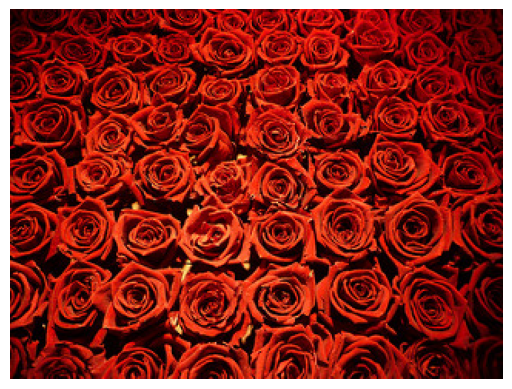

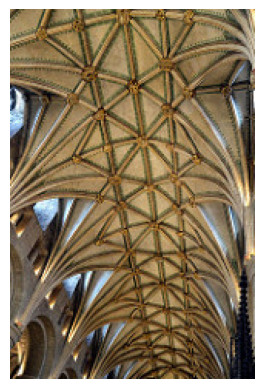

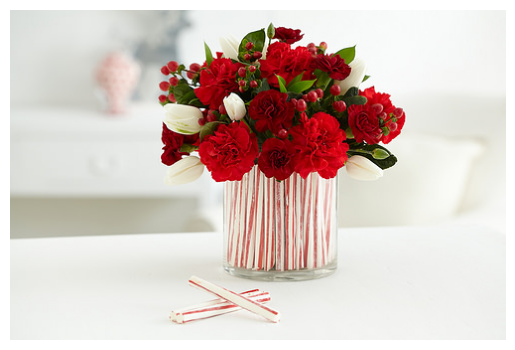

In [ ]:
# [구동 과정 심층 분석] `for i in range(19,22): ...`
# 1. `i`가 19일 때:
#    - `dataset[19]`가 호출됩니다. -> `__getitem__(self, index=19)` 실행.
#    - 19번 인덱스의 경로를 찾아, 디스크에서 해당 이미지 파일을 **처음으로 엽니다**.
#    - 이미지를 텐서로 변환하여 반환합니다.
#    - 반환된 텐서가 `show_image` 함수로 전달되어 화면에 첫 번째 이미지가 그려집니다.
# 2. `i`가 20일 때:
#    - `dataset[20]`이 호출됩니다. -> `__getitem__(self, index=20)` 실행.
#    - 20번 인덱스의 경로를 찾아, **또 다른 새로운 이미지 파일**을 디스크에서 엽니다.
#    - 텐서로 변환하고, `show_image`를 통해 두 번째 이미지가 그려집니다.
# 3. `i`가 21일 때:
#    - 위 과정이 반복되어 세 번째 이미지가 그려집니다.
# 이 과정을 통해, 우리는 매번 필요한 이미지만 그 순간에 디스크에서 불러오는 'Lazy Loading'의 동작을 직접 확인할 수 있습니다.
for i in range(19,22):
    show_image(dataset[i])

# 실습

- scikit-learn에서 California Housing 데이터셋을 불러온 뒤, 입력은 `input_data`에 저장하고 타깃은 `target_data`에 저장하세요.이때 `input_data`와 `target_data` 모두 데이터 타입은 float32로 지정해주세요.

- California Housing 데이터셋의 입력과 타깃을 짝지어 관리하는 커스텀 Dataset 클래스 `CaliforniaHousingDataset`을 정의해 주세요.
   
- 코드 마지막 부분에서 0번 인덱스 데이터를 출력했을 때 다음과 같은 결과가 나와야 합니다.

```
(tensor([   8.3252,   41.0000,    6.9841,    1.0238,  322.0000,    2.5556,
          37.8800, -122.2300]), tensor(4.5260))
```

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 외부 데이터로 '커스텀 데이터셋' 만들기 (실전편) - 디자인 패턴 심층 분석]
#
# [개념적 개요 및 왜 이 작업을 하는가?]
# 이 코드의 목표는, 이전처럼 간단한 리스트가 아닌, 실제 데이터 과학 프로젝트에서 흔히 마주치는
# 외부 라이브러리(`scikit-learn`)가 제공하는 데이터를 PyTorch 딥러닝 모델의 '전용 식자재'로 만드는
# 매우 실전적인 데이터 파이프라인 구축 과정을 마스터하는 것입니다.
# 특히, 똑같은 기능을 하는 `Dataset` 클래스를 두 가지 다른 '디자인 패턴'으로 구현해보면서,
# 소프트웨어 설계의 중요한 개념인 '유연성(Flexibility)'과 '편의성(Convenience)' 사이의 트레이드오프를 이해하게 됩니다.
# 이 과정을 통해, 여러분은 단순히 코드를 따라 치는 것을 넘어, 상황에 따라 더 효율적이고 재사용 가능한 코드를
# 직접 '설계'할 수 있는 능력을 기르게 될 것입니다.
#
# [핵심 비유: 레스토랑 주방의 식자재 관리 시스템]
#
# 1. 데이터 로드 (`scikit-learn`): "신뢰할 수 있는 중앙 공급 업체로부터 '캘리포니아 특선 요리 키트' 배달받기"
#    - `scikit-learn`은 데이터 과학계의 '코스트코'와 같습니다. 품질이 검증된 다양한 데이터들을
#      `.data`(주재료), `.target`(소스) 등이 잘 구분된 '데이터 키트(Bunch 객체)' 형태로 편리하게 제공합니다.
#
# 2. 데이터 준비 (NumPy & `astype`): "배달받은 요리 키트를 중앙 조리대(NumPy)로 옮겨 표준 규격으로 손질하기"
#    - 키트에서 꺼낸 재료를 바로 요리에 쓸 수는 없습니다. 중앙 조리대로 옮겨(NumPy 배열),
#      우리 주방의 모든 기계(PyTorch 모델)가 사용하는 '표준 용량 단위(float32)'로 정확하게 계량하고 손질해야 합니다.
#
# 3. `Dataset` 클래스 설계: "이 손질된 재료를 어떻게 레시피북에 등록할 것인가?"
#    - [디자인 1: 외부 주입 방식] "유연한 총주방장"
#      -> "어떤 조리사든 외부에서 손질해 온 재료를 가져오면, 우리 레시피북에 그대로 등록해 드립니다."
#      -> 장점: 어떤 종류의 데이터든 처리할 수 있어 매우 유연하고 재사용성이 높습니다.
#    - [디자인 2: 내부 처리 방식] "캘리포니아 요리 전문 셰프"
#      -> "손님, 아무것도 신경 쓰지 마세요. 제가 직접 공급 업체에 주문하고 재료 손질까지 다 해서 요리해 드립니다."
#      -> 장점: 사용자는 클래스를 부르기만 하면 되므로 매우 편리합니다.
#
# [지금 무엇을 하고 있는가?]
# 우리는 지금 `scikit-learn`이라는 전문 공급 업체의 데이터를 받아, 두 가지 다른 철학을 가진 '레시피북'을
# 직접 설계하고 비교해보는 과정을 통해, 상황에 맞는 최적의 데이터 공급 시스템을 구축하는
# 데이터 엔지니어이자 소프트웨어 설계자의 역할을 경험하고 있습니다.
# ====================================================================================================


# --- 1. 기본 도구 준비: 라이브러리 불러오기 ---
# [흐름] 본격적인 데이터 처리 및 가공에 앞서, 각 분야의 전문가(라이브러리)들을 작업실로 부르는 과정입니다.

# [구동 과정 심층 분석]
import numpy as np # 수치 계산, 특히 행렬과 벡터 같은 다차원 배열을 빠르고 효율적으로 다루기 위한 NumPy 라이브러리를 `np`라는 별명으로 불러옵니다.
import pandas as pd # 이 코드에서는 직접 사용되지 않지만, 일반적으로 테이블 데이터 처리에 함께 사용되므로 포함되었습니다.

import torch # 딥러닝 모델의 재료가 될 '텐서'를 만들고 다루기 위한 PyTorch 라이브러리.
from torch.utils.data import Dataset # 우리만의 데이터 공급기를 만들기 위한 표준 설계도(추상 클래스).
# [구동 과정 심층 분석] `from sklearn import datasets`
# `scikit-learn` (줄여서 sklearn) 라이브러리 전체에서 `datasets`라는 이름의 '모듈(부품 상자)'을 가져옵니다.
# 이 `datasets` 모듈 안에는 `fetch_california_housing`처럼, 학습용 데이터를 쉽게 내려받을 수 있는 여러 함수들이 들어있습니다.
from sklearn import datasets

In [ ]:
# --- 2. 데이터 로드 및 준비 ("식자재 주문 및 손질") ---
# [흐름] `scikit-learn`이라는 중앙 공급 업체에 '캘리포니아 주택 데이터 키트'를 주문하고,
#      배달된 키트를 열어 주재료(입력)와 소스(정답)를 분리한 뒤, 우리 주방 표준 규격으로 손질합니다.

# [구동 과정 심층 분석] `cal_housing = datasets.fetch_california_housing()`
# 1. `datasets` 모듈 안에 있는 `fetch_california_housing` 함수가 호출됩니다.
# 2. 이 함수는 scikit-learn 라이브러리에 내장되어 있거나, 필요시 웹에서 '캘리포니아 주택 가격' 데이터셋을 다운로드합니다.
# 3. 다운로드한 데이터를 파싱하고 정리하여, 'Bunch'라는 scikit-learn 고유의 특수한 객체 형태로 만듭니다.
#    이 'Bunch' 객체는 파이썬의 딕셔너리와 유사하여, `.`(점)을 이용해 내부의 여러 정보에 쉽게 접근할 수 있습니다. (예: `cal_housing.data`)
# 4. 모든 데이터와 메타데이터(설명 등)가 담긴 이 Bunch 객체가 `cal_housing`이라는 변수에 할당(저장)됩니다.
cal_housing = datasets.fetch_california_housing()

# [구동 과정 심층 분석] `input_data = cal_housing.data.astype(np.float32)`
# 1. `cal_housing.data`: `cal_housing` Bunch 객체의 `data` 속성에 접근합니다. 여기에는 주택의 8가지 특성(중간 소득, 주택 연식 등)이
#    NumPy 배열 형태로 저장되어 있습니다. 이 배열의 기본 데이터 타입은 보통 `float64`입니다.
# 2. `.astype(np.float32)`: `data` 속성에서 꺼내온 NumPy 배열에 대해 `astype` 메서드를 호출합니다.
#    이 메서드는 배열의 모든 원소를 지정된 `np.float32` 타입으로 변환한 **새로운** NumPy 배열을 생성하여 반환합니다.
#    - **왜 이 변환이 필수적인가?**: 딥러닝 연산의 표준은 `float32`입니다. `float64`는 `float32`보다 2배의 메모리를 차지하고
#      GPU 연산 속도도 느리게 만듭니다. 미리 `float32`로 통일해두면, 나중에 PyTorch 모델에 데이터를 넣을 때
#      불필요한 성능 저하나 잠재적 타입 에러를 원천적으로 방지할 수 있습니다. 이것은 매우 중요한 '좋은 습관'입니다.
# 3. 최종적으로 변환된 `float32` 타입의 NumPy 배열이 `input_data` 변수에 저장됩니다.
input_data = cal_housing.data.astype(np.float32)

# [구동 과정 심층 분석] `target_data = cal_housing.target.astype(np.float32)`
# 1. `cal_housing.target`: `cal_housing` Bunch 객체의 `target` 속성에 접근합니다. 여기에는 각 주택의 가격(중간값) 정보가
#    1차원 NumPy 배열 형태로 저장되어 있습니다.
# 2. `.astype(np.float32)`: 이 타겟 데이터 역시 `float32` 타입으로 변환한 새로운 NumPy 배열을 생성합니다.
# 3. 최종적으로 변환된 `float32` 타입의 1차원 NumPy 배열이 `target_data` 변수에 저장됩니다.
target_data = cal_housing.target.astype(np.float32)

In [ ]:
# --- 3. [디자인 패턴 1] 외부에서 데이터를 주입받는 유연한 데이터셋 ---
# [흐름] 첫 번째 디자인 철학: "우리 주방(Dataset)은 어떤 재료든 받아서 처리할 수 있는 유연한 시스템을 갖추자!"
#      데이터를 로드하고 준비하는 책임은 클래스 '외부'에 두고, 클래스는 오직 전달받은 데이터를 '포장'하는 역할만 수행합니다.

# [구동 과정] `CalHousingDataset` 클래스를 `Dataset`을 상속받아 정의합니다.
class CalHousingDataset(Dataset):
    # [구동 과정] 객체 생성 시(`CalHousingDataset(...)`) 호출될 `__init__` 메서드를 정의합니다.
    #            이번에는 외부에서 `input_data`와 `target_data`를 인자로 직접 전달받도록 설계되었습니다.
    def __init__(self, input_data, target_data):
        # [구동 과정] 외부에서 매개변수로 전달받은 `input_data`(NumPy 배열)를 객체 내부의 `self.input_data` 저장고에 저장합니다.
        self.input_data = input_data
        # [구동 과정] 외부에서 전달받은 `target_data`(NumPy 배열)를 객체 내부의 `self.target_data` 저장고에 저장합니다.
        # [설계 철학] 이 클래스는 데이터가 어디서 왔는지 전혀 신경 쓰지 않습니다. 오직 NumPy 배열 형태의 입력과 타겟을
        #           받기만 하면 됩니다. 덕분에 캘리포니아 주택 데이터뿐만 아니라, 보스턴 주택 데이터 등
        #           다른 어떤 데이터라도 이 클래스를 재사용하여 데이터셋으로 만들 수 있습니다. 이것이 '유연성'과 '재사용성'입니다.
        self.target_data = target_data

    # [구동 과정] `len(객체)`가 호출될 때 실행될 `__len__` 메서드를 정의합니다.
    def __len__(self):
        # [구동 과정] `self.input_data` NumPy 배열의 길이(행의 개수)를 계산하여 반환합니다.
        return len(self.input_data)

    # [구동 과정] `객체[index]`가 호출될 때 실행될 `__getitem__` 메서드를 정의합니다.
    def __getitem__(self, index):
        # [구동 과정] `self.input_data`에서 `index`번째 행을, `self.target_data`에서 `index`번째 값을 꺼냅니다.
        #            그리고 `torch.tensor()`를 이용해 각각 PyTorch 텐서로 변환한 뒤, 튜플로 묶어 반환합니다.
        input_tensor = torch.tensor(self.input_data[index])
        target_tensor = torch.tensor(self.target_data[index])
        return input_tensor, target_tensor

In [ ]:
# [구동 과정 심층 분석] `dataset = CalHousingDataset(...)`
# 1. `CalHousingDataset` 클래스의 생성자를 호출합니다.
# 2. `__init__` 메서드가 실행되며, 우리가 `input_data=`와 `target_data=`로 명시적으로 전달한 두 NumPy 배열이
#    `__init__` 메서드의 `input_data`, `target_data` 매개변수로 각각 전달됩니다.
# 3. `__init__` 내부의 코드가 실행되어, 전달받은 두 배열이 새로 생성된 `dataset` 객체의 `self.input_data`와 `self.target_data` 저장고에 저장됩니다.
dataset = CalHousingDataset(input_data=input_data, target_data=target_data)
print("--- 버전 1 (외부 주입 방식) ---")

# [구동 과정] `dataset[0]`이 `dataset` 객체의 `__getitem__` 메서드를 `index=0`으로 호출하여, 반환된 텐서 튜플을 출력합니다.
print(dataset[0])
print()

--- 버전 1 (외부 주입 방식) ---
(tensor([   8.3252,   41.0000,    6.9841,    1.0238,  322.0000,    2.5556,
          37.8800, -122.2300]), tensor(4.5260))



In [ ]:
# --- 4. [디자인 패턴 2] 내부에서 모든 것을 처리하는 간편한 데이터셋 ---
# [흐름] 두 번째 디자인 철학: "우리 주방은 '캘리포니아 스페셜' 전문점! 사용자는 그냥 주문만 하세요. 재료 수급부터 손질까지 제가 다 알아서 합니다!"
#      데이터를 로드하고 준비하는 책임을 클래스 '내부'에 모두 포함시켜, 사용자의 편의성을 극대화합니다.

# [구동 과정] `CalHousingDataset`이라는 동일한 이름으로 클래스를 다시 정의합니다. 파이썬에서는 이전에 정의된 클래스를 새로운 정의로 덮어쓸 수 있습니다.
class CalHousingDataset(Dataset):
    # [구동 과정] 객체 생성 시(`CalHousingDataset()`) 호출될 `__init__` 메서드를 정의합니다. 이번에는 외부에서 받는 인자가 없습니다.
    def __init__(self):
        # [구동 과정 심층 분석] `__init__` 메서드 '내부에서' 데이터 준비의 모든 과정이 순차적으로 실행됩니다.
        # 1. `datasets.fetch_california_housing()`: scikit-learn에 데이터를 주문합니다.
        # 2. `cal_housing.data.astype(np.float32)`: 키트에서 주재료를 꺼내 `float32`로 손질합니다.
        # 3. `self.input_data = ...`: 손질된 주재료를 객체 내부의 저장고에 직접 저장합니다.
        # 4. `cal_housing.target.astype(np.float32)`: 키트에서 소스를 꺼내 `float32`로 손질합니다.
        # 5. `self.target_data = ...`: 손질된 소스를 객체 내부의 저장고에 직접 저장합니다.
        cal_housing = datasets.fetch_california_housing()
        self.input_data = cal_housing.data.astype(np.float32)
        self.target_data = cal_housing.target.astype(np.float32)
        # [설계 철학] 이 클래스를 사용하는 사람은 데이터가 어디서 오는지, 어떻게 손질되는지 전혀 알 필요가 없습니다.
        #           그저 `CalHousingDataset()` 한 줄만 호출하면 모든 것이 준비된 객체를 얻을 수 있습니다. 이것이 '편의성'입니다.
        #           하지만 이 클래스는 오직 캘리포니아 주택 데이터만 처리할 수 있으므로 '재사용성'은 떨어집니다.

    # [구동 과정] `__len__`과 `__getitem__` 메서드는 버전 1과 완벽하게 동일합니다.
    #            데이터가 '어떻게' 저장되었는지는 중요하지 않습니다. 일단 `self.input_data`에 데이터가 저장되고 나면,
    #            그것의 길이를 재거나 특정 인덱스를 꺼내오는 방식은 완전히 동일하기 때문입니다.
    def __len__(self):
        return len(self.input_data)

    def __getitem__(self, index):
        input_tensor = torch.tensor(self.input_data[index])
        target_tensor = torch.tensor(self.target_data[index])
        return input_tensor, target_tensor

In [ ]:
# [구동 과정 심층 분석] `dataset = CalHousingDataset()`
# 1. `CalHousingDataset` 클래스의 생성자를 호출합니다. 이번에는 전달할 인자가 없습니다.
# 2. `__init__` 메서드가 실행되며, 외부의 도움 없이 메서드 내부에서 직접 데이터를 다운로드하고 손질하여 `self.input_data`와 `self.target_data`를 채웁니다.
# 3. 모든 준비가 끝난 객체가 `dataset` 변수에 저장됩니다.
dataset = CalHousingDataset()
print("--- 버전 2 (내부 처리 방식) ---")

# [구동 과정] 이전과 동일하게 `dataset[0]`이 `__getitem__` 메서드를 호출하여 결과를 출력합니다.
print(dataset[0])
print()

--- 버전 2 (내부 처리 방식) ---
(tensor([   8.3252,   41.0000,    6.9841,    1.0238,  322.0000,    2.5556,
          37.8800, -122.2300]), tensor(4.5260))



In [ ]:
# --- 5. 최종 요약 및 심화 ---
# [두 접근 방식의 차이점 요약]
# 1. 버전 1 (외부 주입): **유연하고 재사용 가능**. 마치 다양한 종류의 나사를 조일 수 있는 '드라이버'와 같습니다.
#                      데이터를 다르게 전처리하거나(예: 표준화), 학습/검증/테스트 데이터를 분리하여 주입하는 등 다양한 상황에 대처할 수 있어 더 일반적이고 권장되는 방식입니다.
# 2. 버전 2 (내부 처리): **간편하고 직관적**. 특정 와인병만 딸 수 있는 '전용 오프너'와 같습니다.
#                      특정 데이터셋을 위한 전용 클래스를 만들어 배포하거나, 간단한 실험을 빠르게 진행할 때 유용합니다.

# [구동 과정 심층 분석] 데이터 타입 변환의 중요성을 시각적으로 재확인하는 코드 (이전 설명과 동일한 로직)
print("--- 데이터 타입 변환 심층 분석 ---")
original_data = datasets.fetch_california_housing().target # `.astype` 없이 원본 NumPy 배열(float64)을 가져옵니다.
print("손질 전 원본 데이터 타입:", original_data.dtype)

converted_data = original_data.astype(np.float32) # float32로 명시적으로 변환합니다.
print("손질된 데이터 타입:", converted_data.dtype)

tensor_original = torch.tensor(original_data) # PyTorch는 NumPy의 float64 타입을 존중하여 torch.float64 텐서를 만듭니다.
tensor_converted = torch.tensor(converted_data) # float32 타입을 존중하여 torch.float32 텐서를 만듭니다.
print("손질 전 데이터로 만든 텐서 타입:", tensor_original.dtype)
print("손질한 데이터로 만든 텐서 타입:", tensor_converted.dtype)

# [최종 결론]
# 미리 데이터를 `float32`로 손질하는 것은, PyTorch의 표준 규격에 맞춰 불필요한 연산과 잠재적 에러를 방지하는
# 매우 중요하고 효율적인 코딩 습관입니다.

# 데이터 전처리 고려사항:
# - 특성 스케일링: 각 특성의 스케일이 다르므로 정규화 또는 표준화가 필요할 수 있음
# - 데이터 분할: 학습용, 검증용, 테스트용으로 데이터 분할 필요
# - 배치 처리: DataLoader를 사용하여 미니배치 단위로 데이터 제공

--- 데이터 타입 변환 심층 분석 ---
손질 전 원본 데이터 타입: float64
손질된 데이터 타입: float32
손질 전 데이터로 만든 텐서 타입: torch.float64
손질한 데이터로 만든 텐서 타입: torch.float32


# 데이터 분할

In [ ]:
# ====================================================================================================
# [전체적인 목표 및 개념적 개요]
# 이 코드의 목표는 딥러닝 모델의 '진정한 일반화 성능'을 공정하고 신뢰성 있게 측정하는 것입니다.
# 이를 위해 전체 데이터를 '학습(train)', '검증(validation)', '테스트(test)'라는 세 가지
# 목적이 다른 그룹으로 나누는 이유와 그 과정을 완벽히 이해하는 데 초점을 맞춥니다.
# 모델이 단순히 학습 데이터를 '암기'하는 것이 아니라, 처음 보는 데이터에 대해서도 얼마나
# 잘 예측하는지를 평가하는 것이 최종 목표입니다.
#
# [핵심 비유: 요리 대회 준비 과정]
# 딥러닝 모델 학습을 '셰프(모델)가 요리 대회에 출전하기 위해 훈련하는 과정'에 비유할 수 있습니다.
#
# 1. 전체 데이터셋 (AbaloneDataset): '대회를 위해 주어진 모든 식자재 상자'
#    - 상자 안에는 요리의 재료(input_data)와 정답 레시피(target_data)가 한 쌍으로 들어있습니다.
#
# 2. 학습(Train) 데이터셋: '연습용 주방의 식자재'
#    - 셰프(모델)가 레시피를 보고 칼질, 불 조절 등 기본적인 기술(모델의 가중치/파라미터)을
#      연마하는 데 사용하는 재료입니다. 이 재료는 원하는 만큼 반복해서 사용하며 실력을 키웁니다.
#
# 3. 검증(Validation) 데이터셋: '모의고사용 식자재'
#    - 연습을 마친 셰프가 자신만의 전략(하이퍼파라미터)을 최종 결정하기 위해 치르는 중간 평가입니다.
#
# 4. 테스트(Test) 데이터셋: '본선 대회용 비밀 식자재'
#    - 모든 훈련과 전략 수립이 끝난 셰프의 최종 실력을 **단 한 번만** 평가하기 위해 주어지는,
#      지금까지 한 번도 본 적 없는 미지의 재료입니다. 이 점수가 셰프의 '진짜 실력'을 나타냅니다.
# ====================================================================================================

# --- 1. 기본 라이브러리 및 데이터 준비 ---
# [흐름] 본격적인 요리를 시작하기 전, 주방에 필요한 핵심 도구(라이브러리)들을 선반에서 꺼내는 과정입니다.

# [numpy] '숫자 계산의 달인'. 파이썬에서 행렬, 벡터 같은 다차원 배열을 빠르고 효율적으로 다루게 해주는 필수 라이브러리입니다.
import numpy as np
# [pandas] '데이터 정리의 전문가'. 엑셀 시트처럼 생긴 표(테이블) 형태의 데이터를 읽고, 가공하고, 분석하는 데 최적화된 라이브러리입니다.
import pandas as pd
# [torch] '딥러닝 셰프'. PyTorch 프레임워크의 핵심으로, 딥러닝 모델을 만들고 학습시키는 모든 기능을 제공합니다.
import torch
# [Dataset, random_split] PyTorch의 '보조 도구함'에서 특정 도구 두 개를 꺼냅니다.
# [Dataset]은 데이터를 PyTorch 표준 규격에 맞는 '포장지'로 감싸는 설계도 역할을 합니다.
# [random_split]은 잘 포장된 데이터 묶음을 공정하게, 무작위로 나누어주는 '분배기' 역할을 합니다.
from torch.utils.data import Dataset, random_split

In [ ]:
# --- [1-1. 데이터 로드: "식자재 공급 업체로부터 모든 재료 상자 배달받기"] ---
# [흐름] 인터넷을 통해 원본 식자재(CSV 파일)를 통째로 배달받아 'abalone_df'라는 재료 목록표(DataFrame)에 정리합니다.

# `pd.read_csv()`: CSV 파일을 읽어 DataFrame 객체(메모리 상의 가상 엑셀 시트)로 변환합니다.
# - URL 주소를 직접 입력하면, 웹에서 파일을 다운로드하여 바로 메모리로 가져올 수 있습니다.
# - `names=[...]`: [매우 중요!] 원본 CSV 파일에는 컬럼 이름(헤더)이 없으므로, 우리가 직접 각 열의 이름을 리스트로 지정해줍니다.
#   이 옵션이 없으면 pandas는 데이터의 첫 번째 줄을 헤더로 착각하여 데이터가 손상됩니다.
abalone_df = pd.read_csv(
    'https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv',
    names=['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
           'Viscera weight', 'Shell weight', 'Age']
)

In [ ]:
# --- [1-2. 데이터 전처리: "배달받은 식자재 손질하기"] ---
# [흐름] 하나의 큰 재료 목록표를 모델이 학습할 '요리 재료(input)'와 '정답 레시피(target)'로 분리하고 다듬습니다.

# `abalone_df.drop(columns=['Age'])`: 'Age' 열(정답 레시피)을 '제외한' 나머지 모든 열을 선택합니다.
# `.to_numpy()`: pandas DataFrame을 NumPy 배열(순수한 숫자 격자)로 변환합니다. 딥러닝 모델은 이 형태를 더 잘 처리합니다.
# `.astype(np.float32)`: [핵심!] 배열의 모든 숫자를 '32비트 부동소수점(float32)' 타입으로 통일합니다.
#   - 왜? 1) PyTorch 신경망 연산은 기본적으로 `float32`를 사용합니다. (호환성)
#   -    2) `float64`(NumPy 기본값)보다 메모리를 절반만 사용하고, GPU 계산이 훨씬 빠릅니다. (효율성)
input_data = abalone_df.drop(columns=['Age']).to_numpy().astype(np.float32)

# `abalone_df['Age']`: 'Age' 열'만'을 선택하여 모델이 맞춰야 할 정답(타겟)으로 삼습니다.
target_data = abalone_df['Age'].to_numpy().astype(np.float32)

# --- [1-3. Dataset 클래스 정의: "재료와 레시피를 하나의 '요리 세트'로 포장하기"] ---
# [흐름] 흩어져 있는 input과 target 데이터를 PyTorch 표준 규격에 맞춰, 하나의 '요리 세트'로 포장하는 설계도(클래스)를 만듭니다.
#      이 포장 덕분에 데이터의 '짝'이 절대 흩어지지 않습니다.
class AbaloneDataset(Dataset):
    def __init__(self, input_data, target_data):
        # 생성자 메서드: 데이터셋을 초기화합니다
        # self.input_data: 모델 입력으로 사용될 특성 데이터를 저장합니다
        # self.target_data: 예측 대상인 타겟 값을 저장합니다
        self.input_data = input_data
        self.target_data = target_data

    def __len__(self):
        # 데이터셋의 전체 샘플 수를 반환합니다
        # PyTorch의 DataLoader가 데이터셋 크기를 확인할 때 이 메서드를 호출합니다
        return len(self.input_data)

    def __getitem__(self, index):
        # 특정 인덱스의 데이터 샘플을 반환합니다
        # index: 가져올 데이터 샘플의 인덱스 (0부터 시작)
        input_tensor = torch.tensor(self.input_data[index])  # NumPy 배열을 PyTorch 텐서로 변환
        target_tensor = torch.tensor(self.target_data[index])  # NumPy 배열을 PyTorch 텐서로 변환
        return input_tensor, target_tensor  # (입력 데이터, 타겟 값) 튜플을 반환

# 중요 개념: Dataset 클래스의 역할
# Dataset 클래스는 데이터를 조직화하고 인덱싱하는 표준화된 방법을 제공합니다
# __getitem__ 메서드는 데이터 전처리, 증강, 변환 등의 로직을 캡슐화하는 이상적인 장소입니다

In [ ]:
# --- 2. [핵심] 데이터 분할: 올바른 방법과 잘못된 방법들 ---
# [흐름] 이제 준비된 재료를 학습, 검증, 테스트 세트로 나누는 본 과정에 들어갑니다.
#      먼저 명확한 계획을 세우고, 왜 어떤 방법은 위험하고 어떤 방법이 안전한지 비교하며 심층적으로 이해합니다.

# --- [2-1. 분할 계획 세우기] ---
# [구동 과정] `len(input_data)`로 전체 데이터 개수(3320)를 얻어 `total_size`에 저장합니다.
total_size = len(input_data)
# [구동 과정] 전체 개수에 0.8을 곱하고 정수로 변환(2656)하여 `train_size`에 저장합니다.
train_size = int(total_size * 0.8)
# [구동 과정] 전체 개수에 0.1을 곱하고 정수로 변환(332)하여 `val_size`에 저장합니다.
val_size = int(total_size * 0.1)
# [구동 과정] 전체 개수에서 학습 및 검증 개수를 뺀 나머지(332)를 `test_size`에 저장합니다.
test_size = total_size - train_size - val_size

print("--- [분할 계획] ---")
print(f"총 데이터: {total_size}개")
print(f"분할 계획 -> 학습: {train_size}개, 검증: {val_size}개, 테스트: {test_size}개")

--- [분할 계획] ---
총 데이터: 3320개
분할 계획 -> 학습: 2656개, 검증: 332개, 테스트: 332개


In [ ]:
# --- [2-2. 잘못된 방법 1: 순서대로 자르기] ---
# [문제점] 데이터가 특정 순서(예: 나이순)로 정렬되어 있다면, 각 데이터 그룹이 완전히 다른 특성을 갖게 됩니다.
#         이는 마치 "어린 전복 데이터로만 연습하고, 늙은 전복 데이터로 시험 보는" 것과 같아 공정한 평가가 불가능합니다.
print("--- [잘못된 방법 1] 순서대로 자르기 (결과: 편향된 데이터셋) ---")

# [구동 과정 심층 분석]
# `input_data[:train_size]`: NumPy 배열의 '슬라이싱' 기능.
# 0번 인덱스부터 `train_size - 1` 인덱스까지의 데이터를 잘라내어 `train_inputs_bad1`에 저장합니다.
train_inputs_bad1 = input_data[:train_size]
# `input_data[train_size : train_size + val_size]`: `train_size` 인덱스부터 그 다음 `val_size` 개수만큼의 데이터를 잘라냅니다.
val_inputs_bad1 = input_data[train_size:train_size + val_size]
# `input_data[train_size + val_size :]`: 위에서 사용하고 남은 모든 데이터를 끝까지 잘라냅니다.
test_inputs_bad1 = input_data[train_size + val_size:]
print(f"학습 데이터셋 크기: {len(train_inputs_bad1)}, 검증: {len(val_inputs_bad1)}, 테스트: {len(test_inputs_bad1)}")
print("-> [결론] 크기는 맞지만, 데이터가 섞이지 않아 편향될 위험이 매우 큼!")
print()

--- [잘못된 방법 1] 순서대로 자르기 (결과: 편향된 데이터셋) ---
학습 데이터셋 크기: 2656, 검증: 332, 테스트: 332
-> [결론] 크기는 맞지만, 데이터가 섞이지 않아 편향될 위험이 매우 큼!



In [ ]:
# --- [2-3. 잘못된 방법 2: 입력과 타겟을 '따로따로' 섞기] ---
# [개념] 데이터를 섞어야 한다는 점은 인지했지만, 가장 치명적인 실수를 저지르는 경우입니다.
#        입력(재료)과 타겟(레시피)을 각각 독립적으로 섞어버리면, 재료와 레시피의 짝이 완전히 파괴되어 데이터가 의미를 잃게 됩니다.
print("--- [잘못된 방법 2] 입력과 타겟을 따로 섞기 (결과: 짝이 파괴된 데이터셋) ---")

# [구동 과정 심층 분석] `train_inputs, ... = random_split(input_data, ...)`
# 1. `random_split` 함수가 **첫 번째로** 호출됩니다.
# 2. 내부적으로 0~3319까지의 인덱스를 무작위로 섞습니다. (가정: 첫 번째 섞인 순서 = [501, 2, 3000, ...])
# 3. 이 '첫 번째 섞인 순서'에 따라 `input_data`를 분할하여 `train_inputs` 등의 Subset 객체를 생성합니다.
#    따라서 `train_inputs[0]`은 원본 `input_data`의 501번째 데이터를 가리키게 됩니다.
train_inputs, val_inputs, test_inputs = random_split(input_data, [train_size, val_size, (len(input_data) - train_size - val_size)])

# [구동 과정 심층 분석] `train_targets, ... = random_split(target_data, ...)`
# 1. `random_split` 함수가 **두 번째로, 독립적으로** 호출됩니다.
# 2. 내부적으로 0~3319까지의 인덱스를 **새롭게, 다시** 무작위로 섞습니다. (가정: 두 번째 섞인 순서 = [123, 2500, 4, ...])
# 3. 이 '두 번째 섞인 순서'에 따라 `target_data`를 분할하여 `train_targets` 등의 Subset 객체를 생성합니다.
#    따라서 `train_targets[0]`은 원본 `target_data`의 123번째 데이터를 가리키게 됩니다.
# [치명적 결과]
# `train_inputs[0]` (501번 재료)와 `train_targets[0]` (123번 레시피)는 더 이상 짝이 아닙니다. 데이터의 의미가 완전히 파괴되었습니다.
train_targets, val_targets, test_targets = random_split(target_data, [train_size, val_size, (len(input_data) - train_size - val_size)])
print("-> [결론] 이 방법은 입력(input)과 타겟(target)의 짝이 완전히 망가져서 절대 사용하면 안 됨!")
print()

--- [잘못된 방법 2] 입력과 타겟을 따로 섞기 (결과: 짝이 파괴된 데이터셋) ---
-> [결론] 이 방법은 입력(input)과 타겟(target)의 짝이 완전히 망가져서 절대 사용하면 안 됨!



In [ ]:
# --- [2-4. 올바른 방법: '먼저 포장하고, 나중에 나누기'] ---
# [핵심 철학] "데이터의 짝이 깨질 위험을 원천적으로 차단하기 위해, 재료와 레시피를 하나의 '밀키트(Dataset 객체)'로
#             먼저 단단히 포장한 뒤, 그 밀키트 자체를 무작위로 섞어 나눈다."
print("--- [올바른 방법] 전체를 Dataset으로 감싼 후 random_split 사용 ---")

# [구동 과정 심층 분석] `full_dataset = AbaloneDataset(input_data, target_data)`
# 1. `AbaloneDataset` 클래스의 생성자를 호출하여, `full_dataset`이라는 객체를 생성합니다.
# 2. `__init__` 메서드가 실행되며, `input_data`와 `target_data` NumPy 배열이 객체 내부의 저장고에 안전하게 보관됩니다.
#    이제 `full_dataset` 객체는 3320개의 완벽한 (입력, 타겟) 짝을 모두 품고 있는, 하나의 거대한 '밀키트 묶음'이 되었습니다.
full_dataset = AbaloneDataset(input_data, target_data)
print(f"하나의 '요리 세트 묶음'으로 포장 완료. 총 세트 수: {len(full_dataset)}개")

# [구동 과정 심층 분석] `train_dataset, ... = random_split(...)`
# 1. `random_split` 함수가 '밀키트 묶음'인 `full_dataset` 객체를 통째로 전달받습니다.
# 2. `generator=torch.Generator().manual_seed(42)`:
#    - `torch.Generator()`: 무작위 숫자를 생성하는 '난수 생성기' 기계를 만듭니다.
#    - `.manual_seed(42)`: 이 기계에 '42'라는 '시작점(seed)'을 설정합니다.
#      이렇게 하면 이 기계는 항상 똑같은 순서의 '무작위' 숫자들을 생성하게 됩니다.
#      **이것이 '재현성'의 핵심입니다.** 이 코드를 누가, 언제, 어디서 실행하든 항상 동일하게 데이터가 섞이도록 보장하여,
#      실험 결과를 신뢰하고 비교할 수 있게 만듭니다.
# 3. `random_split`은 이 고정된 난수 생성기를 사용하여, `full_dataset`의 인덱스(0~3319)를 **단 한 번** 무작위로 섞습니다. (가정: [99, 1024, 7, ...])
# 4. 이 '단 하나의 섞인 순서'를 `[train_size, val_size, test_size]`에 맞게 세 조각으로 나눕니다.
# 5. 각 조각(인덱스 리스트)과 원본 `full_dataset`에 대한 참조를 담은 'Subset'이라는 이름의 특별한 객체 3개를 생성하여 반환합니다.
#    이 `Subset` 객체들은 데이터를 직접 복사하지 않고, 원본의 어느 부분을 담당하는지만을 기억하므로 매우 가볍습니다.
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

# [구동 과정 심층 분석] `sample_input, sample_target = train_dataset[0]`
# 1. `train_dataset[0]`이 호출됩니다. `train_dataset`은 Subset 객체입니다.
# 2. `train_dataset`은 자신이 담당하는 섞인 인덱스 리스트의 0번째 값(예: 99)을 확인합니다.
# 3. 그리고 원본인 `full_dataset`에게 "99번 인덱스의 데이터를 주세요"라고 요청합니다.
#    즉, `full_dataset.__getitem__(index=99)`를 내부적으로 호출합니다.
# 4. `AbaloneDataset`의 `__getitem__` 메서드는 약속대로 99번째의 (입력, 타겟) 짝을 완벽한 텐서 튜플로 만들어 반환합니다.
# 5. 이 반환된 튜플이 `sample_input`과 `sample_target` 변수에 각각 할당됩니다.
#    이 과정을 통해, 데이터의 짝이 절대로 깨지지 않음이 보장됩니다.
sample_input, sample_target = train_dataset[0]

print(f"\n올바르게 분할된 학습셋 크기: {len(train_dataset)}, 검증셋: {len(val_dataset)}, 테스트셋: {len(test_dataset)}")
print("-> [결론] 데이터가 무작위로 잘 섞이고, (입력, 타겟)의 짝이 완벽하게 유지된 최상의 결과!")
print("\n--- 학습 데이터셋의 첫 샘플 (무작위) ---")
print("입력(Input):", sample_input)
print("타겟(Target):", sample_target)
print("입력 타입:", sample_input.dtype)

# 중요 개념: 데이터 분할의 필요성
# 머신러닝 모델의 성능을 공정하게 평가하려면 세 가지 데이터 세트가 필요합니다:
# 1. 학습 세트: 모델 파라미터 학습에 사용
# 2. 검증 세트: 하이퍼파라미터 튜닝과 모델 선택에 사용
# 3. 테스트 세트: 최종 모델 성능 평가에 사용 (모델 개발 과정에서 한 번도 사용되지 않은 데이터)

--- [올바른 방법] 전체를 Dataset으로 감싼 후 random_split 사용 ---
하나의 '요리 세트 묶음'으로 포장 완료. 총 세트 수: 3320개

올바르게 분할된 학습셋 크기: 2656, 검증셋: 332, 테스트셋: 332
-> [결론] 데이터가 무작위로 잘 섞이고, (입력, 타겟)의 짝이 완벽하게 유지된 최상의 결과!

--- 학습 데이터셋의 첫 샘플 (무작위) ---
입력(Input): tensor([0.5950, 0.4550, 0.1400, 0.9140, 0.3895, 0.2225, 0.2710])
타겟(Target): tensor(9.)
입력 타입: torch.float32


# 표준화

전복 데이터처럼 수치형 데이터를 사용할 때는, 각 피처마다 평균이 0, 표준편차가 1이 되도록 표준화를 해 주는 경우가 많습니다.

그래야 피처의 스케일에 영향을 받지 않고, 모델을 더 안정적으로 학습시킬 수 있거든요.

파이토치에서 데이터를 표준화할 때는 주로 싸이킷런의 도움을 받습니다.

먼저 싸이킷런 프리프로세싱 모듈에서 스탠다드 스케일러를 임포트하고,,, 바로 스탠다드 스케일러 객체를 만들어 줄게요.

먼저 fit 메소드에 학습 입력 데이터를 넣어 주겠습니다.

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 데이터 표준화(Standardization)]
#
# [개념적 개요]
# 딥러닝 모델이라는 '민감한 미식가'에게 음식을 주기 전에, 모든 재료의 '맛의 단위'를 통일시켜주는 과정입니다.
# 예를 들어, 어떤 재료는 '무게(g)' 단위이고 다른 재료는 '길이(cm)' 단위라면, 모델은 단순히 숫자가 큰 '무게' 쪽을
# 더 중요한 재료라고 착각할 수 있습니다. 표준화는 모든 재료(피처)를 동일한 출발선(평균 0)과 동일한 보폭(표준편차 1)으로
# 만들어 주어, 모델이 오직 재료 자체의 특성에만 집중하도록 돕는 핵심적인 전처리 과정입니다.
#
# [핵심 비유: 과목별 점수 조정]
# '수학(100점 만점)' 점수와 '봉사활동(10점 만점)' 점수를 가진 학생을 평가한다고 상상해봅시다.
# 수학 90점과 봉사 8점은 둘 다 훌륭하지만, 숫자 크기만 보면 모델은 '수학' 점수를 10배 이상 중요하게 여길 수 있습니다.
# 표준화는 두 과목 점수를 모두 '평균 0점, 표준편차 1점'이라는 동일한 기준으로 바꿔주어,
# 어떤 과목이든 공정하게 평가할 수 있도록 만들어주는 것과 같습니다.
# ====================================================================================================


# --- 1. 도구 준비: '표준화 변환기(StandardScaler)' 불러오기 ---
# [흐름] 데이터의 단위를 통일시켜 줄 전문가용 도구를 'scikit-learn'이라는 거대한 공구함에서 꺼내옵니다.

# [코드 구동 과정]
# `from sklearn.preprocessing import StandardScaler`
# 1. 파이썬이 `sklearn` 라이브러리의 `preprocessing` 모듈(전처리 도구 모음)로 찾아갑니다.
# 2. 그 안에서 `StandardScaler`라는 이름의 클래스(설계도)를 찾아서 현재 작업 환경으로 가져옵니다.
#    이제 우리는 이 설계도를 사용해 '표준화 변환기' 객체를 만들 수 있습니다.
from sklearn.preprocessing import StandardScaler

In [ ]:
# --- 2. 변환기 생성 및 '규칙 학습(fit)': 학습 데이터의 특징 파악하기 ---
# [흐름] 아무것도 모르는 상태의 '표준화 변환기'를 만들고, 이 변환기에게 '학습 데이터'를 보여주며
#      데이터를 어떤 기준으로 바꿀지에 대한 '규칙'을 스스로 학습하게 만듭니다.

# [코드 구동 과정]
# `scaler = StandardScaler()`
# 1. `StandardScaler` 설계도를 바탕으로, 실제 작업을 수행할 `scaler`라는 이름의 객체(인스턴스)를 생성합니다.
# 2. 이 시점의 `scaler`는 텅 비어있는 상태입니다. 아직 데이터의 평균이나 표준편차가 얼마인지 전혀 모릅니다.
#    비유하자면, 아직 아무런 레시피도 입력되지 않은 새로운 요리 기계와 같습니다.
scaler = StandardScaler()

# [코드 구동 과정]
# `scaler.fit(train_inputs)`
# 1. `scaler` 객체의 `fit` (학습) 기능을 호출합니다.
# 2. `train_inputs` 데이터를 `fit` 기능에 전달합니다.
# 3. `scaler`는 `train_inputs`의 모든 숫자 각각에 대해, 각 특성(열)의 평균(μ)과 표준편차(σ)를 계산합니다.
# 4. 계산된 평균(μ)과 표준편차(σ) 값들을 `scaler` 객체 내부에 **저장**합니다.
#    이제 `scaler`는 이 값들을 사용하여 앞으로 들어오는 데이터를 표준화할 준비가 되었습니다.
scaler.fit(train_inputs)

StandardScaler()

In [ ]:
# --- 3. '데이터 변환(transform)': 학습된 규칙으로 모든 데이터 변환하기 ---
# [흐름] 이제 '학습 데이터의 규칙'을 완벽히 기억하는 `scaler`를 사용하여,
#      학습, 검증, 테스트 데이터를 모두 동일한 기준으로 변환합니다.

# [코드 구동 과정]
# `train_inputs_scaled = scaler.transform(train_inputs)`
# 1. `scaler` 객체의 `transform` (변환) 기능을 호출합니다.
# 2. `train_inputs` 데이터를 `transform` 기능에 전달합니다.
# 3. `scaler`는 `train_inputs`의 모든 숫자 각각에 대해, 이전에 저장해 둔 규칙(μ와 σ)을 적용합니다.
#    - **적용되는 공식: `표준화된 값 = (원본 값 - 평균 μ) / 표준편차 σ`**
# 4. 이 공식으로 계산된 새로운 값들로 구성된 행렬을 `train_inputs_scaled`라는 새 변수에 저장합니다.
train_inputs_scaled = scaler.transform(train_inputs)

# [코드 구동 과정]
# `val_inputs_scaled = scaler.transform(val_inputs)`
# 1. 검증 데이터(`val_inputs`)에 대해서도 `transform`을 적용합니다.
# 2. **[핵심]** 여기서도 `scaler`는 **새로운 규칙을 배우는 것이 아니라**, 이전에 `train_inputs`로 학습했던
#    **동일한 평균(μ)과 표준편차(σ)를 그대로 사용**하여 변환합니다.
#    이는 모든 데이터를 '하나의 일관된 기준'으로 변환하기 위함입니다.
val_inputs_scaled = scaler.transform(val_inputs)

# [코드 구동 과정]
# `test_inputs_scaled = scaler.transform(test_inputs)`
# 1. 테스트 데이터(`test_inputs`)에도 마찬가지로 `train_inputs`로부터 학습한 규칙을 동일하게 적용합니다.
test_inputs_scaled = scaler.transform(test_inputs)

In [ ]:
# --- 4. 변환 결과 확인: 정말로 단위가 통일되었을까? ---
# [흐름] 표준화가 잘 되었는지 눈으로 직접 확인하는 과정입니다.

# [코드 구동 과정] `print(train_inputs[0])`
# `train_inputs` (NumPy 배열)의 첫 번째 행(0번 인덱스)에 있는 데이터를 출력합니다.
# 표준화되기 전의 원본 숫자들을 보여줍니다.
print(train_inputs[0])

# [코드 구동 과정] `print(train_inputs_scaled[0])`
# `train_inputs_scaled` (새로 생성된 NumPy 배열)의 첫 번째 행을 출력합니다.
# 표준화 공식이 적용된 후의 새로운 숫자들을 보여줍니다. 이 값들은 대부분 0을 중심으로 분포합니다.
print(train_inputs_scaled[0])

# [코드 구동 과정] `train_inputs_scaled.mean(axis=0)`
# 1. `train_inputs_scaled` 배열의 `mean()` (평균 계산) 기능을 호출합니다.
# 2. `axis=0` 옵션은 '열(column)' 방향으로 계산하라는 의미입니다. 즉, 7개 각 특성의 평균을 따로따로 계산합니다.
# 3. 계산된 7개의 평균값을 담은 배열을 출력합니다.
# [결과 분석] 모든 값이 0에 매우 가까운 작은 숫자(예: -1.23e-16)로 출력됩니다.
# 컴퓨터의 부동소수점 계산 오차 때문에 정확히 0이 되지는 않지만, 사실상 0으로 간주할 수 있습니다.
print(train_inputs_scaled.mean(axis=0))

# [코드 구동 과정] `train_inputs_scaled.std(axis=0)`
# 1. `train_inputs_scaled` 배열의 `std()` (표준편차 계산) 기능을 호출합니다.
# 2. `axis=0` 옵션에 따라 각 열(특성)별로 표준편차를 계산합니다.
# 3. 계산된 7개의 표준편차 값을 담은 배열을 출력합니다.
# [결과 분석] 모든 값이 정확히 1로 출력됩니다. 이는 표준화가 완벽하게 이루어졌음을 의미합니다.
print(train_inputs_scaled.std(axis=0))

# [코드 구동 과정] `val_inputs_scaled.mean(axis=0)`
# `val_inputs_scaled` 배열에 대해 위와 동일하게 각 열의 평균을 계산하여 출력합니다.
# [결과 분석] 검증 데이터의 평균은 0에서 약간 벗어난 값을 가집니다.
# 왜냐하면 '학습 데이터의 규칙'으로 변환했기 때문입니다. 이는 데이터 누수 없이 올바르게 처리되었다는 증거입니다.
print(val_inputs_scaled.mean(axis=0))

# [코드 구동 과정] `val_inputs_scaled.std(axis=0)`
# `val_inputs_scaled` 배열에 대해 각 열의 표준편차를 계산하여 출력합니다.
# [결과 분석] 표준편차 역시 1에서 약간 벗어난 값을 가집니다. 이것이 정상적인 결과입니다.
print(val_inputs_scaled.std(axis=0))

[0.65   0.5    0.185  1.4415 0.741  0.2955 0.341 ]
[1.05610181 0.93557554 1.04506102 1.26213689 1.73606025 1.0460065
 0.73463849]
[ 2.09379034e-16  3.19001017e-16 -2.41701321e-16 -1.74621863e-17
  3.60529879e-17 -1.18752795e-17  1.33051201e-16]
[1. 1. 1. 1. 1. 1. 1.]
[-0.0184648  -0.0163378   0.00390564  0.0306993   0.02956499  0.01600674
  0.03500565]
[1.05784786 1.05027258 0.94591078 1.0754193  1.08254259 1.04006472
 1.09497258]


In [ ]:
# --- 5. 최종 단계: 표준화된 데이터로 Dataset 객체 재 생성 ---
# [흐름] 표준화라는 전처리 과정을 마친 새로운 재료들을 다시 PyTorch가 사용할 수 있는 '요리 세트'로 포장합니다.

# [코드 구동 과정]
# 원본 데이터(`train_inputs`) 대신, 이제 '표준화된' 데이터(`train_inputs_scaled` 등)를 사용하여
# 이전에 정의해 둔 `AbaloneDataset` 설계도로 새로운 객체들을 만듭니다.
# 이제 이 데이터셋들은 모델 학습에 바로 사용될 수 있는, 완벽하게 준비된 재료들입니다.
train_dataset = AbaloneDataset(train_inputs_scaled, train_targets)
val_dataset = AbaloneDataset(val_inputs_scaled, val_targets)
test_dataset = AbaloneDataset(test_inputs_scaled, test_targets)

In [ ]:
# --- 6. [보너스] 역변환(inverse_transform): 표준화된 데이터를 원래대로 되돌리기 ---
# [흐름] 모델이 예측한 결과(표준화된 값)를 사람이 이해할 수 있는 원래의 단위로 되돌리고 싶을 때 사용합니다.

# [코드 구동 과정]
# `scaler.inverse_transform(...)`
# 1. `scaler`는 이전에 학습했던 평균(μ)과 표준편차(σ)를 여전히 기억하고 있습니다.
# 2. 이 값을 이용해 `원본 값 = (표준화된 값 * 표준편차 σ) + 평균 μ` 라는 역연산을 수행합니다.
# 3. `train_dataset[0][0]`는 표준화된 학습 데이터의 첫 번째 샘플의 '입력 텐서'를 의미합니다.
#    `inverse_transform`은 리스트나 2D 배열을 입력으로 기대하므로 `[]`로 감싸줍니다.
scaler.inverse_transform([train_dataset[0][0]])

array([[0.64999998, 0.5       , 0.185     , 1.44149995, 0.741     ,
        0.29550001, 0.34099999]])

# 데이터 로더

In [ ]:
# ====================================================================================================
# [이번 학습의 목표: 데이터 로더(DataLoader)]
#
# [개념적 개요]
# 대용량의 데이터를 딥러닝 모델에게 효율적으로 공급하는 '자동 급식 시스템'을 만드는 과정입니다.
# 수만, 수백만 개의 데이터(식자재)를 한번에 메모리에 올리는 것은 비효율적이고 불가능에 가깝습니다.
# DataLoader는 전체 데이터(Dataset)라는 거대한 '식자재 창고'에서, 모델이 한 번에 소화할 수 있는 양만큼의
# '미니 배치(mini-batch)'라는 작은 식판을 만들어 체계적으로 전달해주는 역할을 합니다.
#
# [핵심 비유: 거대한 도서관과 조교]
# - Dataset: 수천 권의 책이 꽂혀있는 '거대한 도서관'.
# - DataLoader: 당신(모델)을 돕는 '똑똑한 조교'.
# 당신이 조교에게 "이제부터 공부를 시작할 건데, 책 4권(`batch_size=4`)씩 가져다줘. 그리고 매번 다른 순서로 무작위로(`shuffle=True`) 뽑아줘!"
# 라고 지시하면, 조교는 도서관을 뛰어다니며 당신의 요구에 맞춰 책을 가져다줍니다. 당신은 책을 읽는(학습하는) 데에만 집중할 수 있습니다.
# ====================================================================================================


# --- 1. 모든 재료 준비 (이전 단계 요약) ---
# [흐름] DataLoader를 사용하기 전에, 이전 단계들에서 했던 것처럼 라이브러리를 불러오고,
#      데이터를 다운로드하여 Tensor로 변환할 수 있는 Dataset 객체까지 만드는 과정입니다.

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset

In [ ]:
# CSV 파일에서 데이터 로드 [코드 구동 과정] CSV 파일에서 데이터를 읽어 pandas DataFrame으로 변환합니다.
# Abalone(전복) 데이터셋은 전복의 신체 측정값과 나이를 포함하고 있습니다.
abalone_df = pd.read_csv(
    'https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv',
    names=['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
           'Viscera weight', 'Shell weight', 'Age']
)

# 입력 데이터와 타겟 데이터 분리
# 입력 데이터: 전복의 신체 측정값 (7개 특성)
# 타겟 데이터: 전복의 나이 (예측 대상)
# [구동 과정] 아래 라인은 여러 작업이 순차적으로 실행됩니다. (오른쪽으로 한 단계씩 진행)
# 1. `abalone_df.drop(columns=['Age'])`: `abalone_df` DataFrame에서 'Age' 열을 제거한 새로운 DataFrame을 임시로 생성합니다.
# 2. `.to_numpy()`: 임시 생성된 DataFrame을 NumPy 배열(순수한 숫자 행렬) 형태로 변환합니다.
# 3. `.astype(np.float32)`: 변환된 NumPy 배열의 모든 숫자 타입을 'float32'로 변경합니다.
# 4. 최종적으로 생성된 float32 타입의 NumPy 배열이 `input_data` 변수에 저장됩니다.
input_data = abalone_df.drop(columns=['Age']).to_numpy().astype(np.float32)

# [구동 과정] 아래 라인도 여러 작업이 순차적으로 실행됩니다.
# 1. `abalone_df['Age']`: `abalone_df` DataFrame에서 'Age' 열 하나만 선택합니다.
# 2. `.to_numpy()`: 선택된 'Age' 열을 NumPy 배열로 변환합니다.
# 3. `.astype(np.float32)`: 이 배열의 숫자 타입을 'float32'로 변경합니다.
# 4. 최종 결과물인 1차원 NumPy 배열이 `target_data` 변수에 저장됩니다.
target_data = abalone_df['Age'].to_numpy().astype(np.float32)

In [ ]:
abalone_df.head()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Age
0,0.435,0.335,0.110,0.334,0.1355,0.0775,0.0965,7
1,0.585,0.450,0.125,0.874,0.3545,0.2075,0.2250,6
2,0.655,0.510,0.160,1.092,0.3960,0.2825,0.3700,14
3,0.545,0.425,0.125,0.768,0.2940,0.1495,0.2600,16
4,0.545,0.420,0.130,0.879,0.3740,0.1695,0.2300,13


In [ ]:
# 사용자 정의 Dataset 클래스 정의
# [구동 과정] `AbaloneDataset`이라는 이름의 새로운 클래스(객체 설계도)를 정의합니다.
#             이 설계도는 PyTorch의 `Dataset` 클래스가 가진 규칙과 기능을 상속받습니다.
class AbaloneDataset(Dataset):
    # [구동 과정] 이 클래스로 객체를 만들 때(`AbaloneDataset(...)`) 호출될 `__init__` 초기화 메서드를 정의합니다.
    def __init__(self, input_data, target_data):
        # [구동 과정] 객체가 생성될 때 받은 `input_data`를 객체 내부의 `self.input_data` 변수에 저장합니다.
        self.input_data = input_data
        # [구동 과정] 객체가 생성될 때 받은 `target_data`를 객체 내부의 `self.target_data` 변수에 저장합니다.
        self.target_data = target_data

    # [구동 과정] `len(객체)`가 호출될 때 실행될 `__len__` 메서드를 정의합니다.
    def __len__(self):
        # [구동 과정] 객체 내부에 저장된 `self.input_data`의 전체 길이(데이터 개수)를 반환합니다.
        return len(self.input_data)

    # [구동 과정] `객체[index]` 형식으로 특정 데이터를 요청할 때 실행될 `__getitem__` 메서드를 정의합니다.
    def __getitem__(self, index):
        # [구동 과정] 객체 내부의 `self.input_data`에서 `index`번째 데이터를 꺼내 PyTorch 텐서로 변환하고 `input_tensor` 변수에 저장합니다.
        input_tensor = torch.tensor(self.input_data[index])
        # [구동 과정] 객체 내부의 `self.target_data`에서 `index`번째 데이터를 꺼내 PyTorch 텐서로 변환하고 `target_tensor` 변수에 저장합니다.
        target_tensor = torch.tensor(self.target_data[index])
        # [구동 과정] 생성된 두 텐서를 하나의 튜플(쌍)으로 묶어서 반환합니다.
        return input_tensor, target_tensor

In [ ]:
# [구동 과정] `torch.utils.data` 모듈에서 `random_split` 함수를 현재 작업 환경으로 가져옵니다.
from torch.utils.data import random_split

# --- [분할 계획 세우기] ---
# [구동 과정] `len(input_data)`로 전체 데이터 개수(3320)를 얻어 `total_size`에 저장합니다.
total_size = len(input_data)
# [구동 과정] 전체 개수에 0.8을 곱하고 정수로 변환(2656)하여 `train_size`에 저장합니다.
train_size = int(total_size * 0.8)
# [구동 과정] 전체 개수에 0.1을 곱하고 정수로 변환(332)하여 `val_size`에 저장합니다.
val_size = int(total_size * 0.1)
# [구동 과정] 전체 개수에서 학습 및 검증 개수를 뺀 나머지(332)를 `test_size`에 저장합니다.
test_size = total_size - train_size - val_size


# # --- [!!! 매우 중요: 잘못된 데이터 분할 방식 !!!] ---
# # [흐름] 아래 코드는 입력(input)과 정답(target) 데이터를 '따로따로' 무작위 분할하고 있습니다.
# #      이는 이전에 배웠던 '잘못된 방법 2'에 해당하며, 심각한 오류를 유발합니다.

# # [구동 과정] `random_split` 함수가 `input_data`를 주어진 크기(`[2656, 332, 332]`)에 따라 무작위로 섞어 3개의 `Subset` 객체로 나눕니다.
# #            이때 사용된 무작위 순서는 이 함수 호출 시에만 유효합니다.
# #            나눠진 3개의 `Subset` 객체가 각각 `train_inputs`, `val_inputs`, `test_inputs` 변수에 저장됩니다.
# train_inputs, val_inputs, test_inputs = random_split(
#     input_data, [train_size, val_size, (len(input_data) - train_size - val_size)]
# )

# # [구동 과정] **또 다른** `random_split` 함수가 **새롭게** 호출됩니다.
# #            이 함수는 `target_data`를 주어진 크기에 따라 **이전과는 다른, 새로운 무작위 순서**로 섞어 3개의 `Subset` 객체로 나눕니다.
# #            나눠진 3개의 `Subset` 객체가 각각 `train_targets`, `val_targets`, `test_targets` 변수에 저장됩니다.
# # [결론] 두 번의 `random_split` 호출은 서로 다른 무작위 순서를 사용하므로, `train_inputs`와 `train_targets`의 데이터 짝이 완전히 파괴됩니다.
# train_targets, val_targets, test_targets = random_split(
#     target_data, [train_size, val_size, (len(input_data) - train_size - val_size)]
# )

In [ ]:
# train_inputs = input_data[:train_size]
# train_targets = target_data[:train_size]

# val_inputs = input_data[train_size: train_size + val_size]
# val_targets = target_data[train_size: train_size + val_size]

# test_inputs = input_data[train_size + val_size:]
# test_targets = target_data[train_size + val_size:]

In [ ]:
# --- [2-4. 올바른 방법: '먼저 포장하고, 나중에 나누기'] ---
# [핵심 철학] "데이터의 짝이 깨질 위험을 원천적으로 차단하기 위해, 재료와 레시피를 하나의 '밀키트(Dataset 객체)'로
#             먼저 단단히 포장한 뒤, 그 밀키트 자체를 무작위로 섞어 나눈다."
print("--- [올바른 방법] 전체를 Dataset으로 감싼 후 random_split 사용 ---")

# [구동 과정 심층 분석] `full_dataset = AbaloneDataset(input_data, target_data)`
# 1. `AbaloneDataset` 클래스의 생성자를 호출하여, `full_dataset`이라는 객체를 생성합니다.
# 2. `__init__` 메서드가 실행되며, `input_data`와 `target_data` NumPy 배열이 객체 내부의 저장고에 안전하게 보관됩니다.
#    이제 `full_dataset` 객체는 3320개의 완벽한 (입력, 타겟) 짝을 모두 품고 있는, 하나의 거대한 '밀키트 묶음'이 되었습니다.
full_dataset = AbaloneDataset(input_data, target_data)
print(f"하나의 '요리 세트 묶음'으로 포장 완료. 총 세트 수: {len(full_dataset)}개")

# [구동 과정 심층 분석] `train_dataset, ... = random_split(...)`
# 1. `random_split` 함수가 '밀키트 묶음'인 `full_dataset` 객체를 통째로 전달받습니다.
# 2. `generator=torch.Generator().manual_seed(42)`:
#    - `torch.Generator()`: 무작위 숫자를 생성하는 '난수 생성기' 기계를 만듭니다.
#    - `.manual_seed(42)`: 이 기계에 '42'라는 '시작점(seed)'을 설정합니다.
#      이렇게 하면 이 기계는 항상 똑같은 순서의 '무작위' 숫자들을 생성하게 됩니다.
#      **이것이 '재현성'의 핵심입니다.** 이 코드를 누가, 언제, 어디서 실행하든 항상 동일하게 데이터가 섞이도록 보장하여,
#      실험 결과를 신뢰하고 비교할 수 있게 만듭니다.
# 3. `random_split`은 이 고정된 난수 생성기를 사용하여, `full_dataset`의 인덱스(0~3319)를 **단 한 번** 무작위로 섞습니다. (가정: [99, 1024, 7, ...])
# 4. 이 '단 하나의 섞인 순서'를 `[train_size, val_size, test_size]`에 맞게 세 조각으로 나눕니다.
# 5. 각 조각(인덱스 리스트)과 원본 `full_dataset`에 대한 참조를 담은 'Subset'이라는 이름의 특별한 객체 3개를 생성하여 반환합니다.
#    이 `Subset` 객체들은 데이터를 직접 복사하지 않고, 원본의 어느 부분을 담당하는지만을 기억하므로 매우 가볍습니다.
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

# [구동 과정 심층 분석] `sample_input, sample_target = train_dataset[0]`
# 1. `train_dataset[0]`이 호출됩니다. `train_dataset`은 Subset 객체입니다.
# 2. `train_dataset`은 자신이 담당하는 섞인 인덱스 리스트의 0번째 값(예: 99)을 확인합니다.
# 3. 그리고 원본인 `full_dataset`에게 "99번 인덱스의 데이터를 주세요"라고 요청합니다.
#    즉, `full_dataset.__getitem__(index=99)`를 내부적으로 호출합니다.
# 4. `AbaloneDataset`의 `__getitem__` 메서드는 약속대로 99번째의 (입력, 타겟) 짝을 완벽한 텐서 튜플로 만들어 반환합니다.
# 5. 이 반환된 튜플이 `sample_input`과 `sample_target` 변수에 각각 할당됩니다.
#    이 과정을 통해, 데이터의 짝이 절대로 깨지지 않음이 보장됩니다.
sample_input, sample_target = train_dataset[0]

print(f"\n올바르게 분할된 학습셋 크기: {len(train_dataset)}, 검증셋: {len(val_dataset)}, 테스트셋: {len(test_dataset)}")
print("-> [결론] 데이터가 무작위로 잘 섞이고, (입력, 타겟)의 짝이 완벽하게 유지된 최상의 결과!")
print("\n--- 학습 데이터셋의 첫 샘플 (무작위) ---")
print("입력(Input):", sample_input)
print("타겟(Target):", sample_target)
print("입력 타입:", sample_input.dtype)

# 중요 개념: 데이터 분할의 필요성
# 머신러닝 모델의 성능을 공정하게 평가하려면 세 가지 데이터 세트가 필요합니다:
# 1. 학습 세트: 모델 파라미터 학습에 사용
# 2. 검증 세트: 하이퍼파라미터 튜닝과 모델 선택에 사용
# 3. 테스트 세트: 최종 모델 성능 평가에 사용 (모델 개발 과정에서 한 번도 사용되지 않은 데이터)

--- [올바른 방법] 전체를 Dataset으로 감싼 후 random_split 사용 ---
하나의 '요리 세트 묶음'으로 포장 완료. 총 세트 수: 3320개

올바르게 분할된 학습셋 크기: 2656, 검증셋: 332, 테스트셋: 332
-> [결론] 데이터가 무작위로 잘 섞이고, (입력, 타겟)의 짝이 완벽하게 유지된 최상의 결과!

--- 학습 데이터셋의 첫 샘플 (무작위) ---
입력(Input): tensor([0.5950, 0.4550, 0.1400, 0.9140, 0.3895, 0.2225, 0.2710])
타겟(Target): tensor(9.)
입력 타입: torch.float32


In [ ]:
# --- 데이터 표준화 및 Dataset 객체 생성 (이전 단계와 동일) ---
# [흐름] 분할된 데이터를 표준화하고, 다시 Dataset 객체로 포장합니다.

# [구동 과정] `StandardScaler` 클래스의 설계도를 바탕으로, 아직 아무런 정보가 없는 비어있는 `scaler` 객체를 생성합니다.
scaler = StandardScaler()
# [구동 과정] `scaler` 객체의 `fit` 메서드를 호출합니다. `train_inputs`(Subset 객체)의 모든 데이터를 대상으로
#            각 열(feature)별 평균과 표준편차를 계산한 뒤, 그 결과를 `scaler` 객체 내부에 저장합니다.
scaler.fit(train_inputs)

StandardScaler()

In [ ]:
# [구동 과정] `scaler` 객체의 `transform` 메서드를 호출합니다. `scaler`가 기억하고 있는 규칙(평균, 표준편차)을 이용해
#            `train_inputs`의 모든 데이터를 표준화한 후, 그 결과를 `train_inputs_scaled` 변수에 저장합니다.
train_inputs_scaled = scaler.transform(train_inputs)
# [구동 과정] 동일한 `scaler`의 `transform` 메서드를 호출하여 `val_inputs`의 모든 데이터를 표준화하고, 결과를 `val_inputs_scaled`에 저장합니다.
val_inputs_scaled = scaler.transform(val_inputs)
# [구동 과정] 동일한 `scaler`의 `transform` 메서드를 호출하여 `test_inputs`의 모든 데이터를 표준화하고, 결과를 `test_inputs_scaled`에 저장합니다.
test_inputs_scaled = scaler.transform(test_inputs)

# [구동 과정] `AbaloneDataset` 클래스의 `__init__` 메서드를 호출합니다. `train_inputs_scaled`와 `train_targets`를 인자로 전달하여
#            이 두 데이터를 내부에 포함하는 `train_dataset` 객체를 생성합니다.
train_dataset = AbaloneDataset(train_inputs_scaled, train_targets)
# [구동 과정] 위와 동일하게 `val_dataset` 객체를 생성합니다.
val_dataset = AbaloneDataset(val_inputs_scaled, val_targets)
# [구동 과정] 위와 동일하게 `test_dataset` 객체를 생성합니다.
test_dataset = AbaloneDataset(test_inputs_scaled, test_targets)

In [ ]:
# --- 2. [핵심] DataLoader 생성 및 사용 ---
# [흐름] 이제 잘 포장된 '데이터셋(Dataset)'을 '자동 급식 시스템(DataLoader)'에 넣어,
#      모델이 학습할 수 있는 '미니 배치' 단위로 데이터를 꺼내보는 과정입니다.

# [구동 과정] `torch.utils.data` 모듈에서 `DataLoader` 클래스(설계도)를 현재 작업 환경으로 가져옵니다.
from torch.utils.data import DataLoader

# [구동 과정] `DataLoader` 클래스의 `__init__` 메서드를 호출하여, 학습용 데이터를 공급할 `train_dataloader` 객체를 생성합니다.
#            이때 전달되는 인자들은 `train_dataloader` 객체의 동작 방식을 결정하는 중요한 설정값이 됩니다.
#            `train_dataset`: 데이터를 가져올 원본 창고.
#            `batch_size=4`: 한 번에 4개씩 데이터를 묶을 것.
#            `shuffle=True`: 데이터를 꺼내기 전에 순서를 무작위로 섞을 것.
#            `drop_last=True`: 마지막에 4개가 안되는 배치는 버릴 것.
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, drop_last=True)

# [구동 과정] `DataLoader` 클래스를 이용해 검증용 데이터를 공급할 `val_dataloader` 객체를 생성합니다.
#            `shuffle`이 `False`이므로, 이 로더는 항상 순서대로 데이터를 꺼내옵니다.
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [ ]:
# --- 3. DataLoader 동작 확인 ---
# [흐름] 생성된 `DataLoader`가 어떻게 동작하는지, 반복문(for loop)을 통해 직접 배치를 하나 꺼내봅니다.

# [구동 과정] `for` 반복문이 `train_dataloader` 객체를 대상으로 시작됩니다. `train_dataloader`는 반복 가능한(iterable) 객체입니다.
#            반복문이 시작될 때, `train_dataloader`는 내부적으로 첫 번째 배치를 생성하기 위한 작업을 시작합니다.
#            (인덱스 섞기 -> 4개 뽑기 -> `__getitem__` 4번 호출 -> 결과 묶기)
#            생성된 첫 번째 배치(2개의 텐서로 구성된 튜플)가 `train_batch` 변수에 할당됩니다.
for train_batch in train_dataloader:
    # [구동 과정] `train_batch` 튜플의 첫 번째 원소(인덱스 0), 즉 입력 데이터 배치 텐서를 화면에 출력합니다.
    print(f'input batch: {train_batch[0]}')
    # [구동 과정] `train_batch` 튜플의 두 번째 원소(인덱스 1), 즉 타겟 데이터 배치 텐서를 화면에 출력합니다.
    print(f'target batch: {train_batch[1]}')
    # [구동 과정] 입력 배치 텐서의 `.size()` 메서드를 호출하여 그 크기(shape) 정보를 화면에 출력합니다.
    print(train_batch[0].size())
    # [구동 과정] `break` 문이 실행되어, 첫 번째 반복만 마치고 `for` 루프를 즉시 탈출합니다.
    break

input batch: tensor([[ 0.8894,  0.9859,  0.5840,  0.4913,  0.4618,  0.3238,  0.5483],
        [ 1.2228,  1.4390,  0.6993,  0.8639,  0.5184,  0.5918,  1.1574],
        [-0.7773, -0.8767, -0.6838, -0.9369, -0.8599, -0.7118, -0.9565],
        [ 0.3894,  0.2812,  0.2382,  0.0091,  0.1359, -0.2212,  0.0467]],
       dtype=torch.float64)
target batch: tensor([11.,  7.,  9., 10.])
torch.Size([4, 7])


In [ ]:
# drop_last 매개변수의 효과를 설명하기 위한 예제
# 검증 데이터셋의 크기가 332개이고 배치 크기를 300으로 설정한 경우

len(val_dataset) # 300 + 32

332

In [ ]:
# --- [보너스] `drop_last` 매개변수 효과 심층 분석 ---
# [흐름] 전체 데이터 개수와 배치 크기가 딱 맞아떨어지지 않을 때 `drop_last`가 어떤 역할을 하는지 확인합니다.

# [구동 과정] `DataLoader` 클래스를 이용해 새로운 `val_dataloader` 객체를 생성하고, 기존의 `val_dataloader` 변수를 덮어씁니다.
#            이때 `batch_size`는 300, `drop_last`는 `True`로 설정됩니다.
val_dataloader = DataLoader(
    val_dataset,
    batch_size=300,
    shuffle=True,
    drop_last=True
)

# [구동 과정] `for` 반복문이 새로 생성된 `val_dataloader`를 대상으로 시작됩니다.
# 1. `val_dataloader`는 첫 번째 배치를 생성합니다. 전체 332개 데이터 중 300개를 무작위로 뽑아 배치를 만듭니다.
#    이 배치가 `val_batch` 변수에 할당되고, `for` 루프 내부의 코드들이 실행됩니다.
# 2. 루프의 첫 번째 반복이 끝나고, `for`문은 `val_dataloader`에게 다음 배치를 요청합니다.
# 3. `val_dataloader`는 남은 데이터가 32개임을 확인합니다. 이 개수는 `batch_size`(300)보다 작습니다.
# 4. `drop_last=True` 설정에 따라, 이 32개짜리 불완전한 배치는 버려집니다.
# 5. 더 이상 반환할 배치가 없으므로, `for` 반복문은 종료됩니다. 결과적으로 이 루프는 단 한 번만 실행됩니다.
for val_batch in val_dataloader:
    # [구동 과정] `val_batch`에 담긴 첫 번째(이자 마지막) 배치의 정보를 화면에 출력합니다.
    print(f'\n--- drop_last=True일 때의 배치 ---')
    print(f'input batch shape: {val_batch[0].shape}')
    print(f'target batch shape: {val_batch[1].shape}')


--- drop_last=True일 때의 배치 ---
input batch shape: torch.Size([300, 7])
target batch shape: torch.Size([300])
